## Maternal Health Risk


- Задача: создать прогностическую модель рисков беременных.
- Метрика: решаете сами
- Особенности: В последних ячейках необходимо вывести метрики и матрицу ошибок на трейне и тесте.

**Описание данных:**

`Age`: Age in years when a woman is pregnant.

`SystolicBP`: Upper value of Blood Pressure in mmHg, another significant attribute during pregnancy.

`DiastolicBP`: Lower value of Blood Pressure in mmHg, another significant attribute during pregnancy.

`BS`: Blood glucose levels is in terms of a molar concentration, mmol/L.

`HeartRate`: A normal resting heart rate in beats per minute.

`Risk Level`: Predicted Risk Intensity Level during pregnancy considering the previous attribute.

## Загрузка данных, исследовательский анализ

### Загрузка библиотек и пр

In [ ]:
!pip install phik -q
!pip install catboost -q
!pip install sweetviz -q

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

import joblib

import sweetviz as sv

import time

import sklearn
import phik

import warnings
warnings.filterwarnings("ignore")

# загружаем классы для подготовки данных
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer, KNNImputer
from imblearn.over_sampling import SMOTE, BorderlineSMOTE

# импортируем классы SearchCV
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

# загружаем нужные модели
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyRegressor, DummyClassifier

# загружаем функции для работы с метриками
from sklearn.metrics import (
    f1_score,
    #r2_score, mean_squared_error, mean_absolute_error,
    confusion_matrix, #recall_score, precision_score, accuracy_score,
    roc_auc_score, #make_scorer
)

import lightgbm as lgb
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier, Pool

In [ ]:
RANDOM_STATE = 654321
TEST_SIZE = 0.3

In [ ]:
np.random.seed(RANDOM_STATE)

### Загрузка данных и знакомство с ними

In [ ]:
import os

pth1 = '/datasets/Maternal Health Risk Data Set.csv'
pth2 = '/content/Maternal Health Risk Data Set.csv'

if os.path.exists(pth1):
    risk = pd.read_csv(pth1, sep=',')
elif os.path.exists(pth2):
    risk = pd.read_csv(pth2, sep=',')
else:
    print('PathError')

In [ ]:
# Посмотрим на датасет
display(risk.head(5))
display(risk.info())

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          1014 non-null   int64  
 1   SystolicBP   1014 non-null   int64  
 2   DiastolicBP  1014 non-null   int64  
 3   BS           1014 non-null   float64
 4   BodyTemp     1014 non-null   float64
 5   HeartRate    1014 non-null   int64  
 6   RiskLevel    1014 non-null   object 
dtypes: float64(2), int64(4), object(1)
memory usage: 55.6+ KB


None

Таким образом, перед нами небольшой датасет состоящий всего из 1014 строк, 6 признаков и имеющий целевой столбец риска здоровью.
Столбцы:
- `Age`	- возраст
- `SystolicBP` - систолическое давление
- `DiastolicBP`	- диастолическое давление
- `BS` - сахар крови
- `BodyTemp`	- температура тела
- `HeartRate` - пульс
- `RiskLevel` - степень риска

In [ ]:
# Проверим еще раз пропуски
risk.isna().sum().sum()

np.int64(0)

In [ ]:
#приводим названия столбцов к snake_case
risk.columns = (risk.columns
                .str.replace('(?<=[a-z])(?=[A-Z])', '_', regex=True)
                .str.lower()
             )

In [ ]:
risk.columns

Index(['age', 'systolic_bp', 'diastolic_bp', 'bs', 'body_temp', 'heart_rate',
       'risk_level'],
      dtype='object')

In [ ]:
risk['risk_level'].unique()

array(['high risk', 'low risk', 'mid risk'], dtype=object)

Это категории, их всего три. Заменим на числовые значения.

In [ ]:
risk['risk_level'] = risk['risk_level'].replace('high risk', 2)
risk['risk_level'] = risk['risk_level'].replace('low risk', 0)
risk['risk_level'] = risk['risk_level'].replace('mid risk', 1)

In [ ]:
risk['risk_level'].unique()

array([2, 0, 1])

Перед нами задача классификации. По данным о возрасте, систолическом и диастолическом давлении, сахаре крови, температуре тела и ЧСС необходимо сортировать риски на три категории: 0, 1, 2.

**Features**: 'age', 'systolic_bp', 'diastolic_bp', 'bs', 'body_temp', 'heart_rate'

**Target**: 'risk_level'   (**Values**: 0, 1, 2)

### Очистка данных и исследовательский анализ

In [ ]:
# Посмотрим дубликаты
risk.duplicated().sum()

np.int64(562)

**Получается, из 1014 строк 562 полных дубликата.**
Удалим дубли, они не помогут нашей модели обучаться, зато могут привести к переобучению.

In [ ]:
risk = risk.drop_duplicates(keep = 'first').reset_index(drop = True)

In [ ]:
risk.describe()

,age,systolic_bp,diastolic_bp,bs,body_temp,heart_rate,risk_level
count,452.000000,452.000000,452.000000,452.000000,452.000000,452.000000,452.000000
mean,29.194690,110.553097,75.418142,8.346173,98.692478,73.949115,0.730088
std,13.767379,17.872282,13.754578,2.829209,1.410897,8.156973,0.833169
min,10.000000,70.000000,49.000000,6.000000,98.000000,7.000000,0.000000
25%,19.000000,90.000000,65.000000,6.900000,98.000000,70.000000,0.000000
50%,25.000000,120.000000,80.000000,7.500000,98.000000,76.000000,0.000000
75%,35.000000,120.000000,86.000000,7.900000,98.000000,80.000000,1.000000
max,70.000000,160.000000,100.000000,19.000000,103.000000,90.000000,2.000000


Посмотрев статистики, можно сделать следующие выводы:
- `Age` Беременные в возрасте от 10 до 70 лет (технически это возможно, поэтому данные считаем верными) с медианным возрастом 25 лет и средним 29,2 лет. Первый и третий квартили - 19 и 35 лет соответственно.
- `systolic_bp` Систолическое длавление в пределах от 70 до 160 (это возможно, данные считаем верными), с медианой 120 и средним 110,6. Первый и третий квартили 90 и 120 соответственно
- `diastolic_bp` Диастолическое давление в значениях от 49 до 100, с медианой 80, средним значением 75,4 (данные корректны), первый и третий квартили 65 и 86 соответсвенно
- `bs` Глюкоза крови в значениях от 6 до 19 (значения возможны, 19 - гипергликемия, но совместимо с жизнью, считаем данные корректны) с медианой 7,5, средним 8,3 и первый и третий квартили 6,9 и 7,9 соответственно (видимо, максимальное значение здесь редкое значение)
- `body_temp` Температура указана явно в Кельвинах, в пределах от 98 до 103 (корректные данные для температуры тела в Кельвинах) с медианой 98, средним 98,7 и первый и третий квартили 98 и 98 соответственно
- `heart_rate` ЧСС в пределах от 7 (**с этим значением требуется разобраться, что это - ошибка или беременная при смерти**) до 90 с медианой 76, средним 73,9 и первый и третий квратили 70 и 80 соответственно (эти данные считаем корректны)

In [ ]:
np.VisibleDeprecationWarning = UserWarning
report = sv.analyze([risk, "Maternal Risk"])

                                             |          | [  0%]   00:00 -> (? left)

In [ ]:
report.show_html('Maternal Risk.html')

Report Maternal Risk.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.



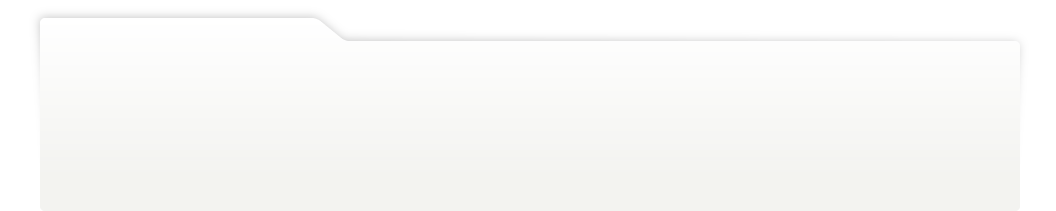
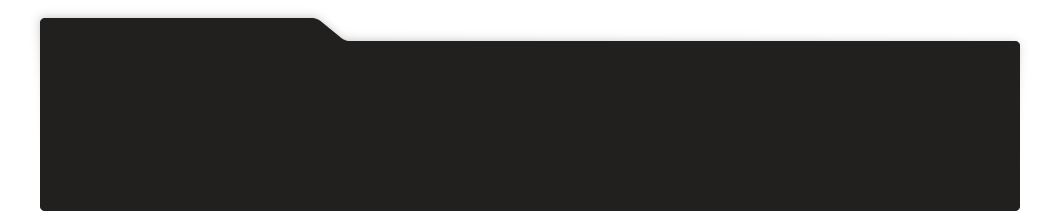
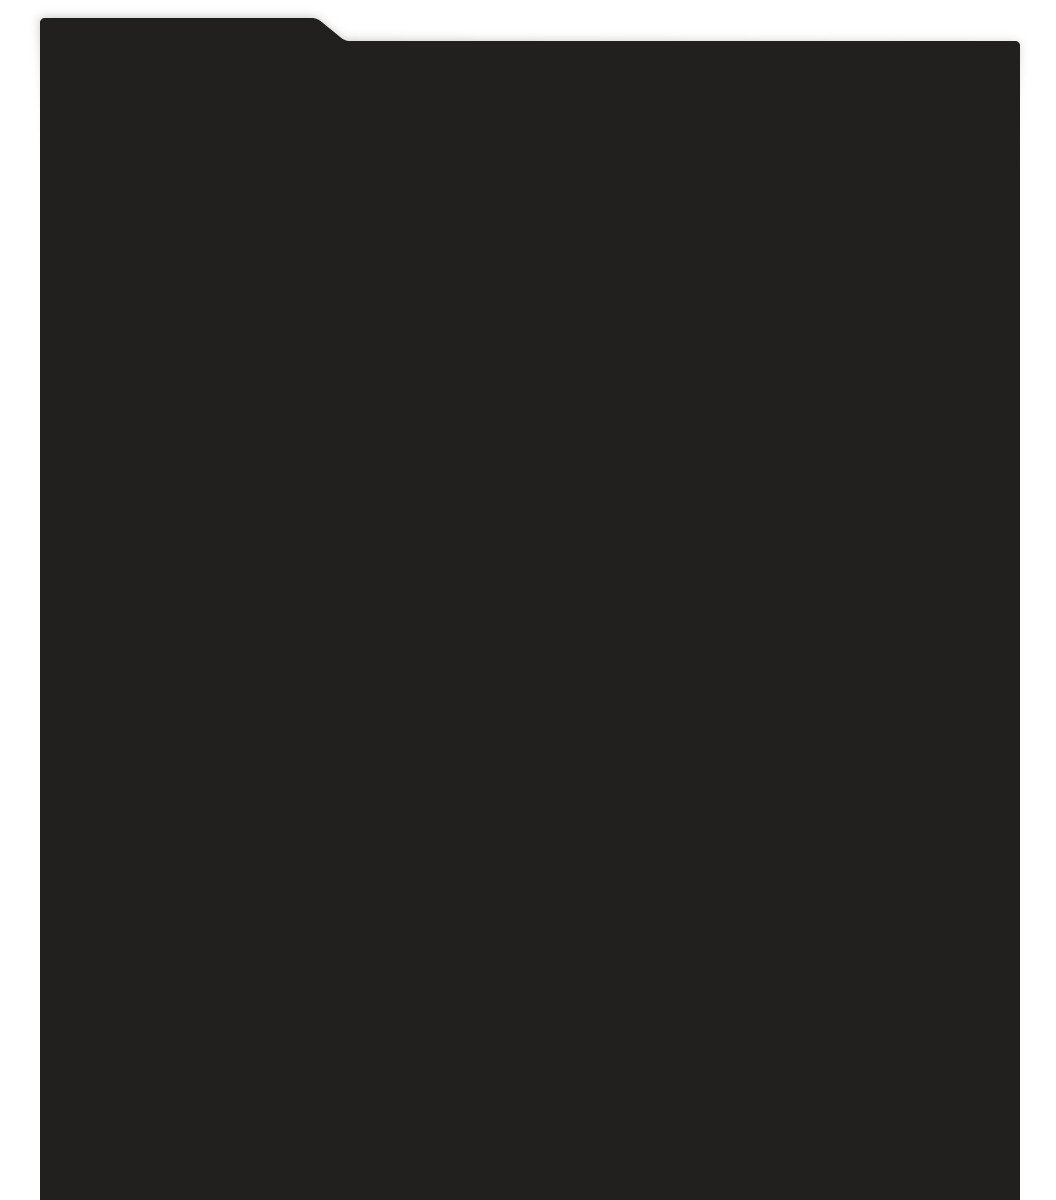
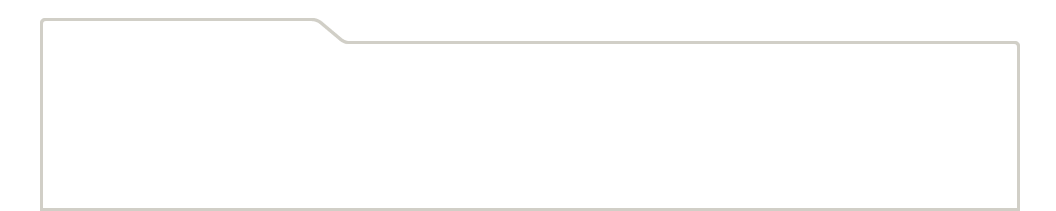
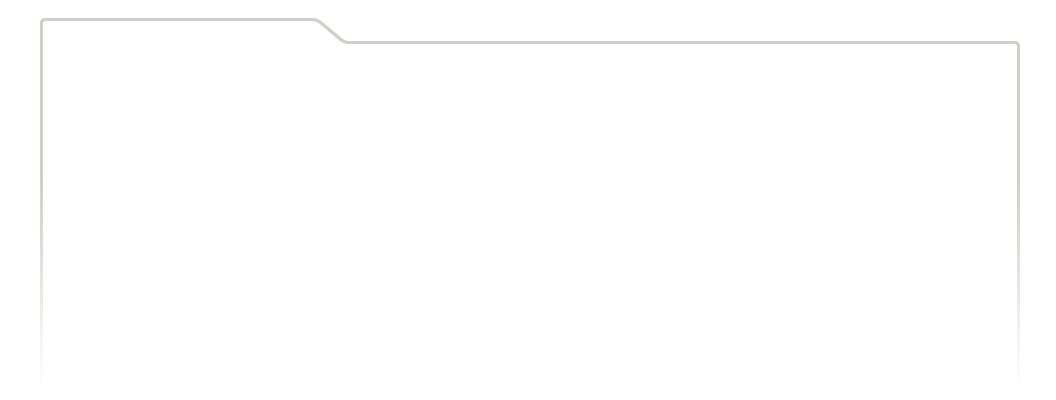
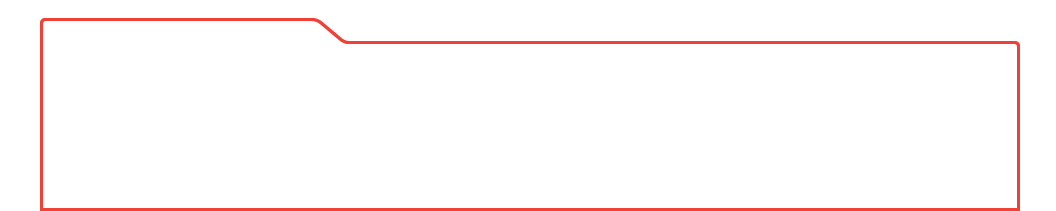
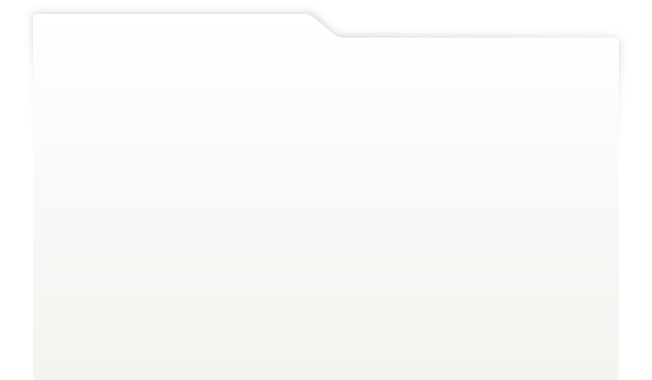
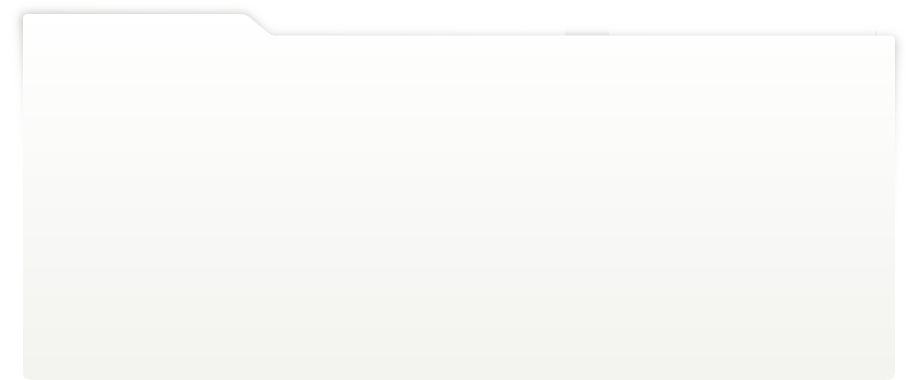
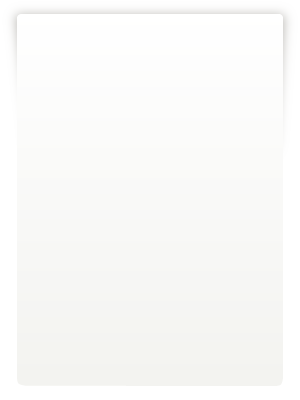
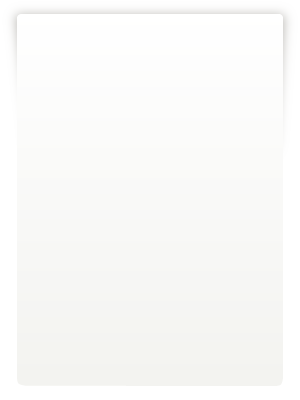
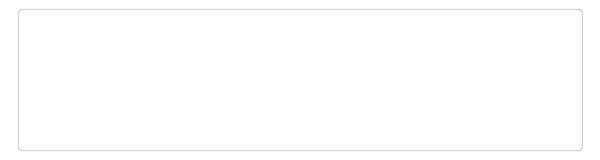
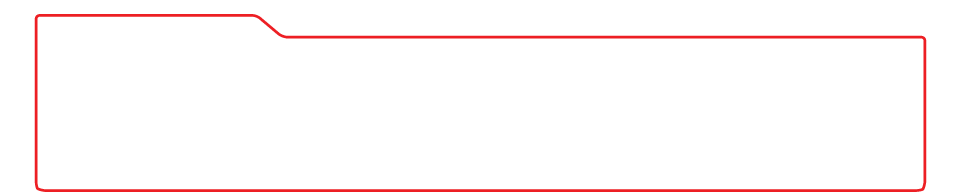
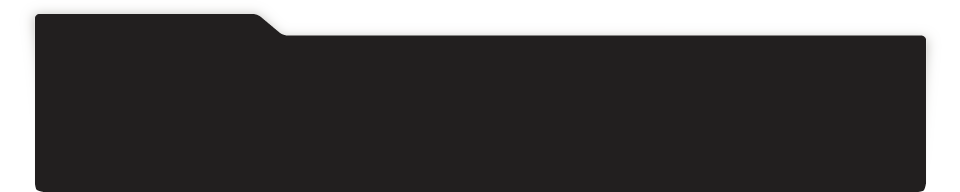
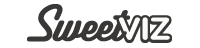
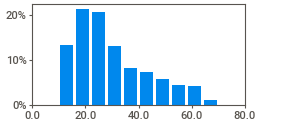
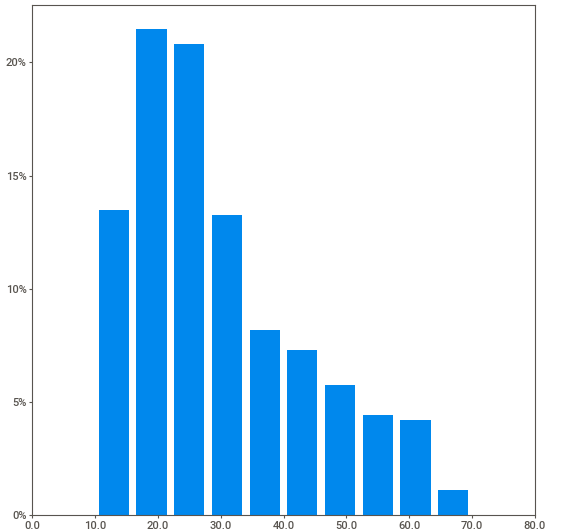
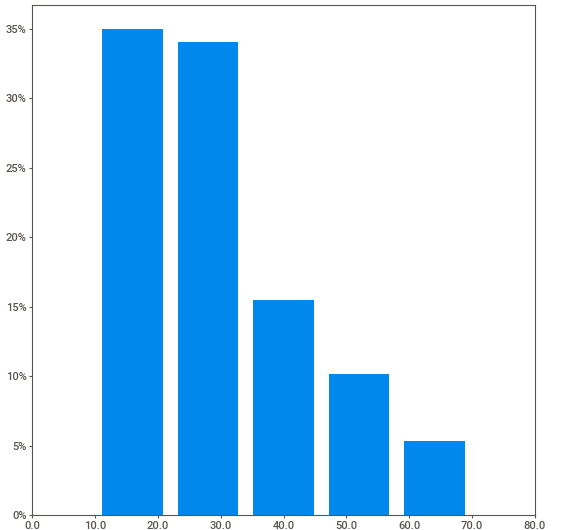
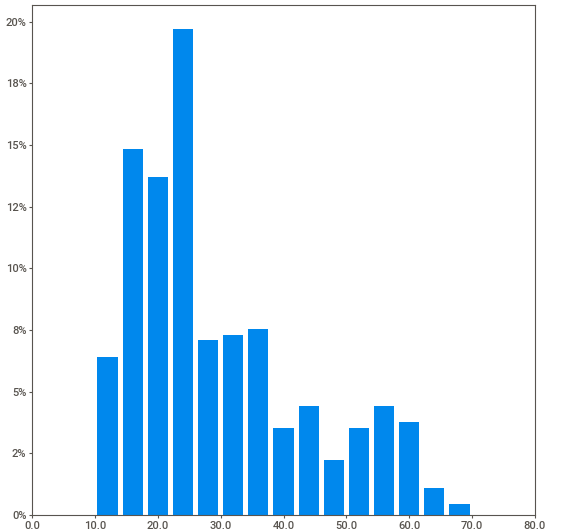
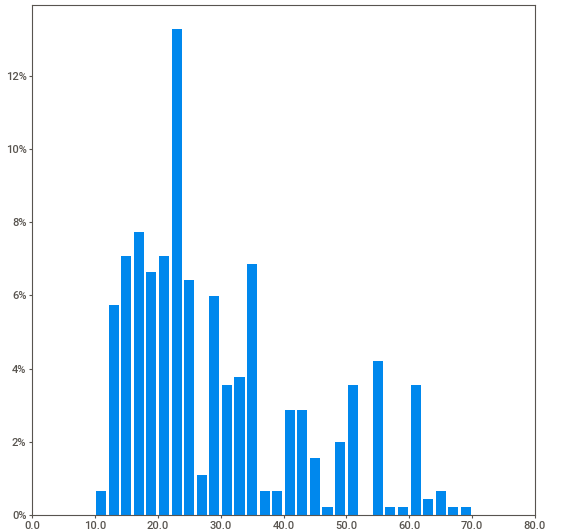
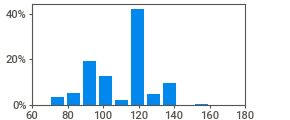
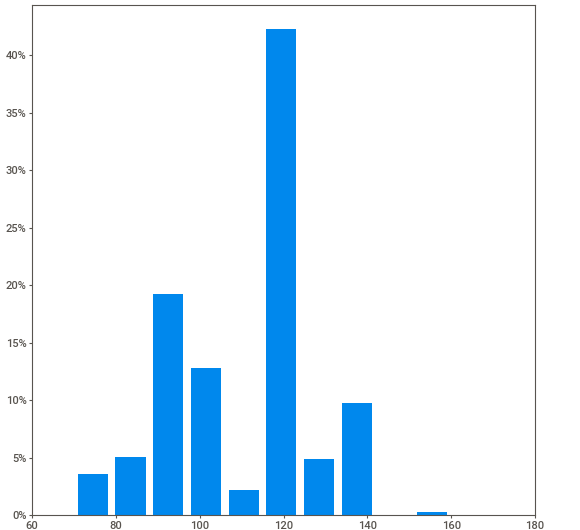
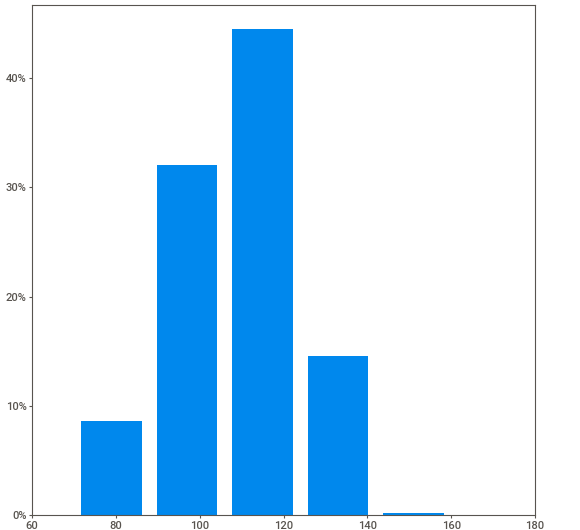
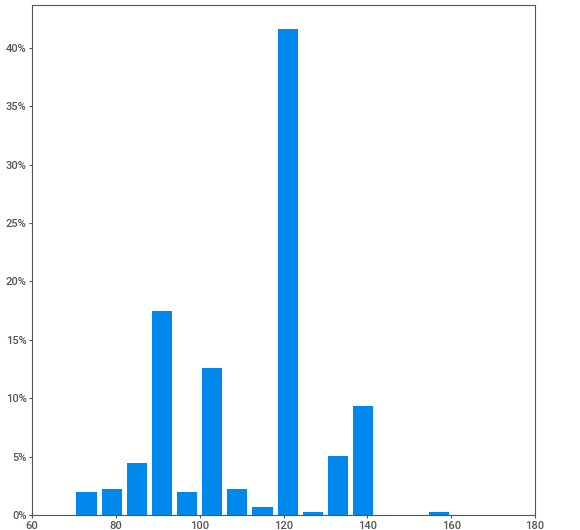
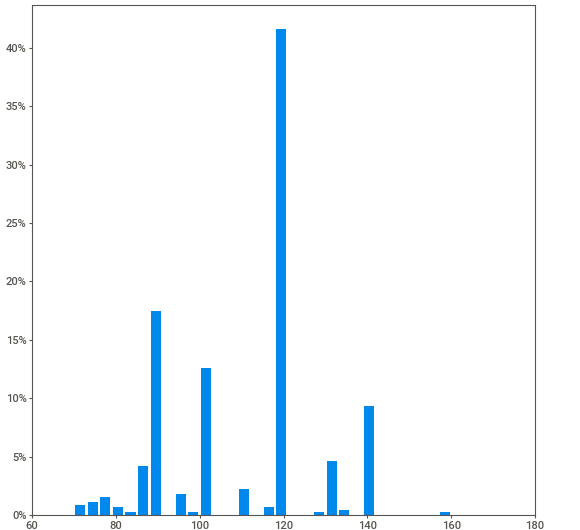
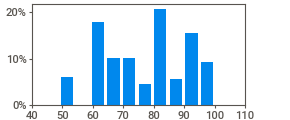
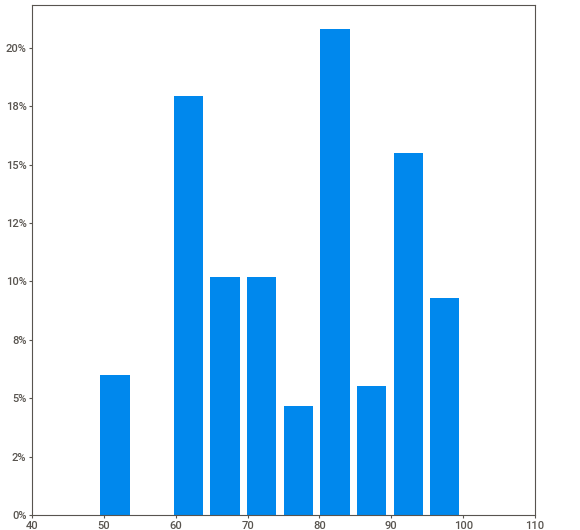
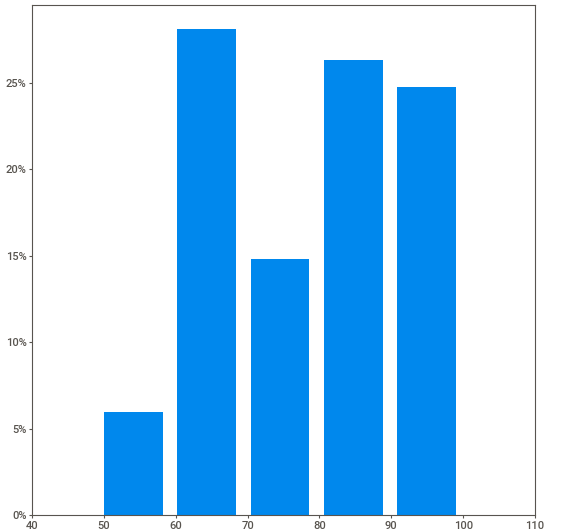
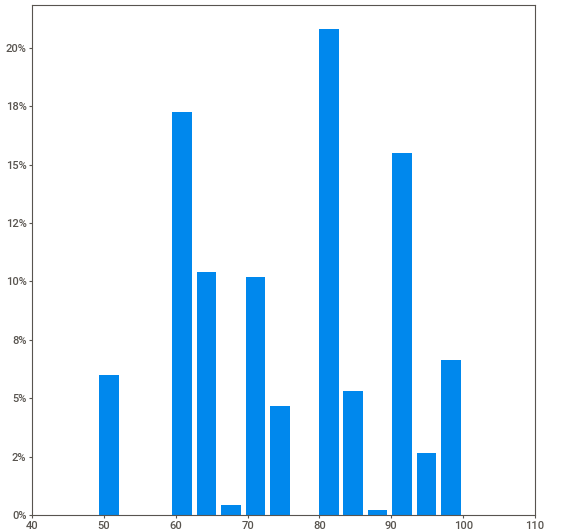
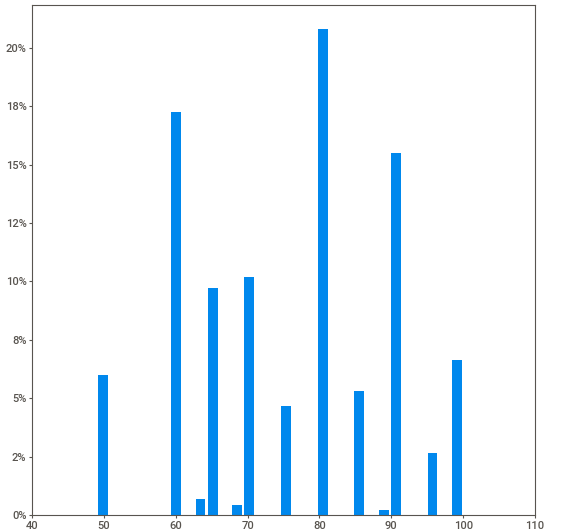
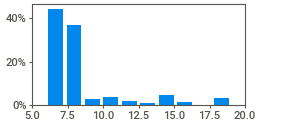
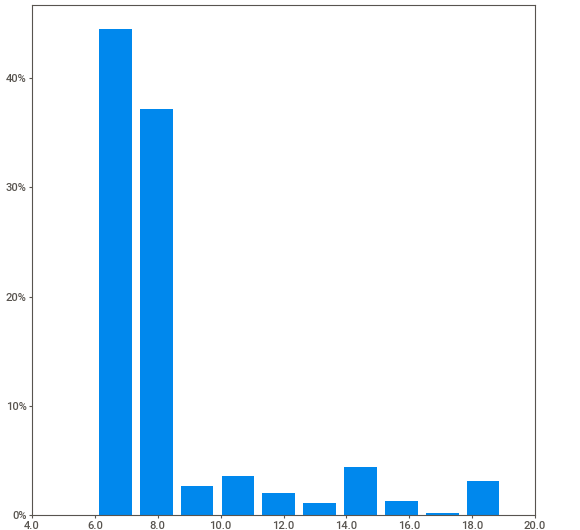
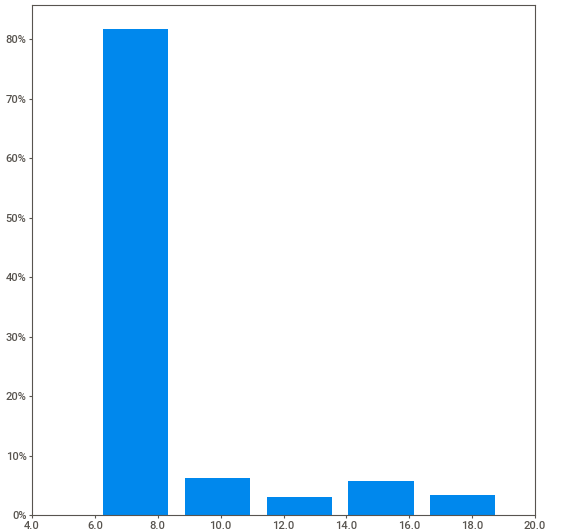
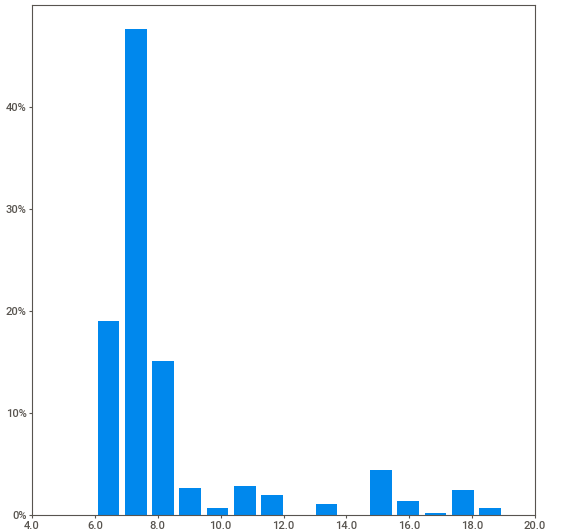
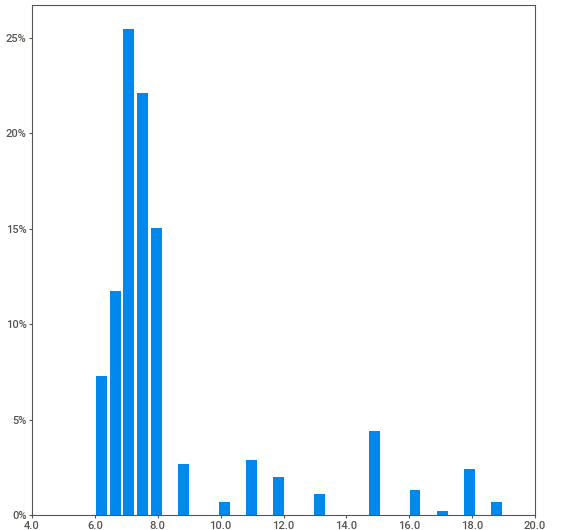
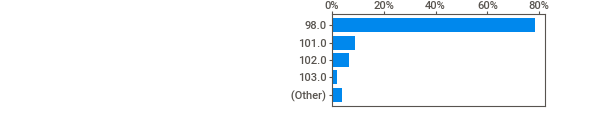
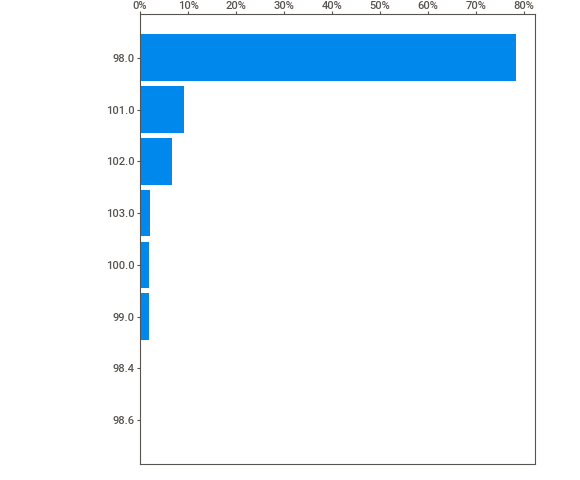
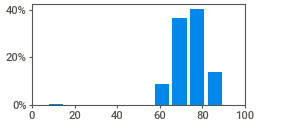
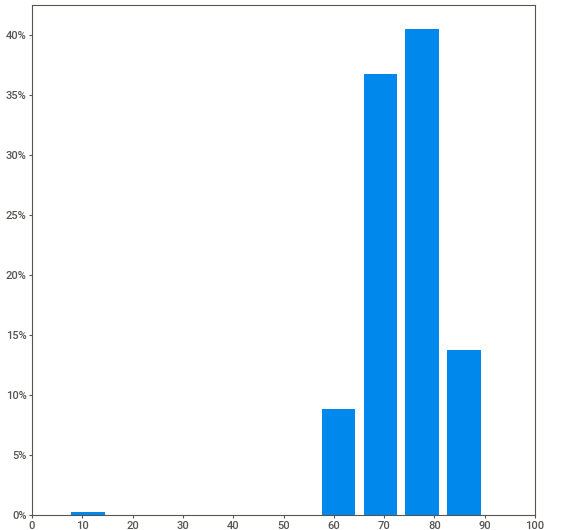
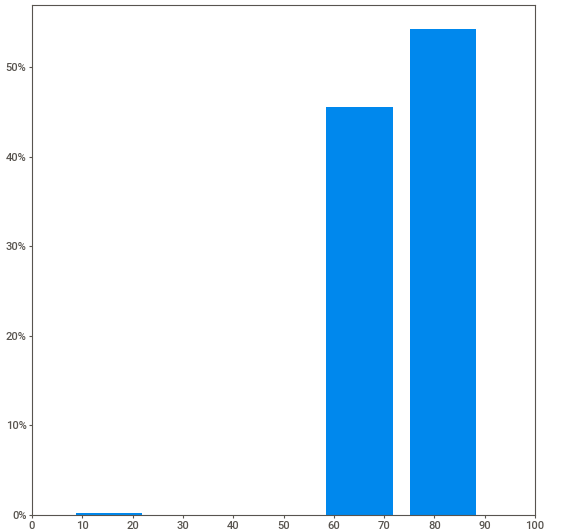
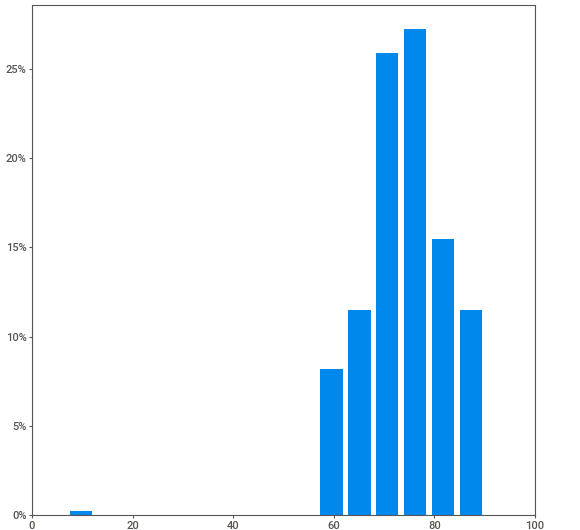
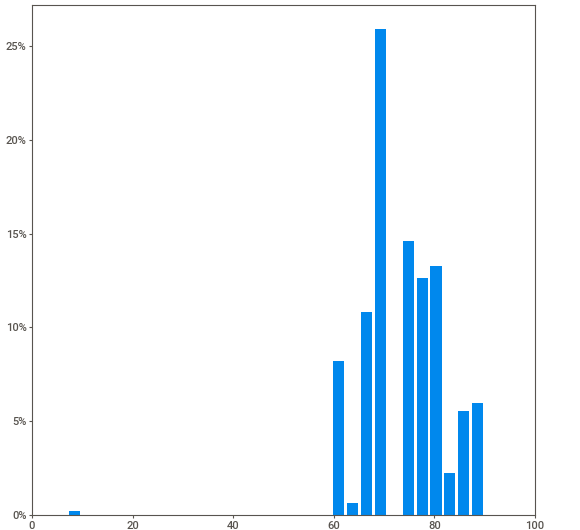
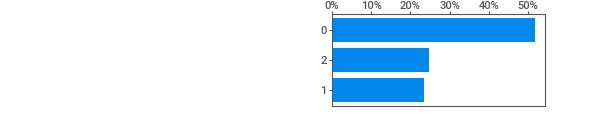
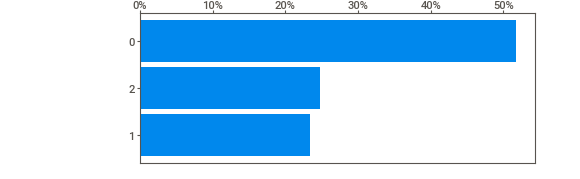
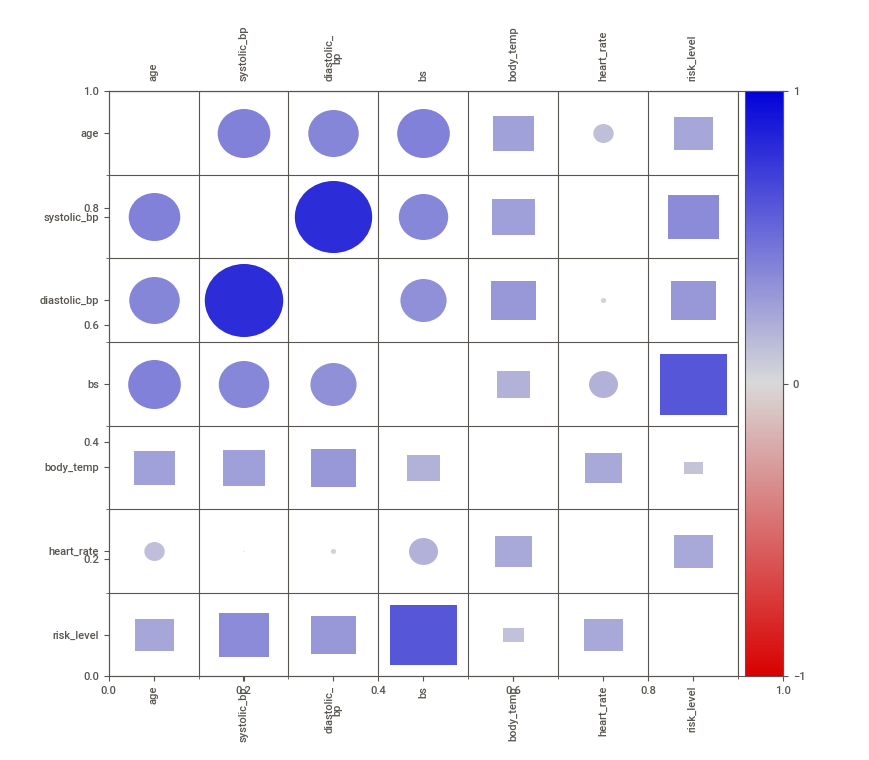
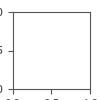

In [ ]:
from IPython.display import HTML
HTML(filename='/content/Maternal Risk.html')

Итак, датасет содержит:
- 452 строк
- 0 DUPLICATES
- 7 столбцов, из которых:
 - 2 категорийных (температура тела и целевой столбец - риск)
 - 5 числовых
 - 0 текстовых

 Пропусков  нет

- Возраст: распределение близко к нормальному, со сдвигом влево, что неудивительно, учитывая, что у нас обьект - беременные женщины. Коррелирует с сахором крови, систолическим и диастолическим давлением (коэффициент пирсена 0.38, 0.38 и 0.35 соотвественно), практически не коррелирует с целевым столбцом (корреляция 0.19)
- Систолическое и диастолическое давления. Коррелируют между собой, не коррелируют с пульсом, слабо коррелируют с риском (0.33 и 0.26).
- Сахар крови. Основные значения между 6 и 8,5 примерно. Эти значсения нормальны для беременных. Остальные значения - превышения и какой-то общей картины в них не наблюдается (мало данных, чтобы они сложились в распределение). Коррелирует с риском с коэффициентом 0.58
- Температура тела. Значение в градусах Фаренгейта. Основное значение 98 - это норма. Не коррелирует с целевым столбцом. Слабо коррелирует с другими признаками.
- Пульс. Распределение похоже на нормальное, с максимумом в значениях между 70 и 80, есть выброс в значении 7. С риском коррелирует слабо.
- В целевом столбце классы неуравновешены, около 50% низкий риск и приблизительно по 25% средний и высокий риски
 Наибольшая корреляция целевого столбца с сахаром крови.

Выведем строку с данным значением:

In [ ]:
# Посмотрим на строку, где у пациентки ЧСС равно 7
string = risk.loc[risk['heart_rate'] == 7]
string


,age,systolic_bp,diastolic_bp,bs,body_temp,heart_rate,risk_level
342,16,120,75,7.9,98.0,7,0


Девушка 16ти лет с низким риском, с идеальным давлением и температурой тела не может иметь ЧСС 7. Считаем, что это ошибка ввода данных, пропущен ноль. Изменим 7 на 70.

In [ ]:
risk.loc[risk.heart_rate == 7, 'heart_rate'] = 70
# проверка
risk.loc[risk['heart_rate'] == 7]

,age,systolic_bp,diastolic_bp,bs,body_temp,heart_rate,risk_level


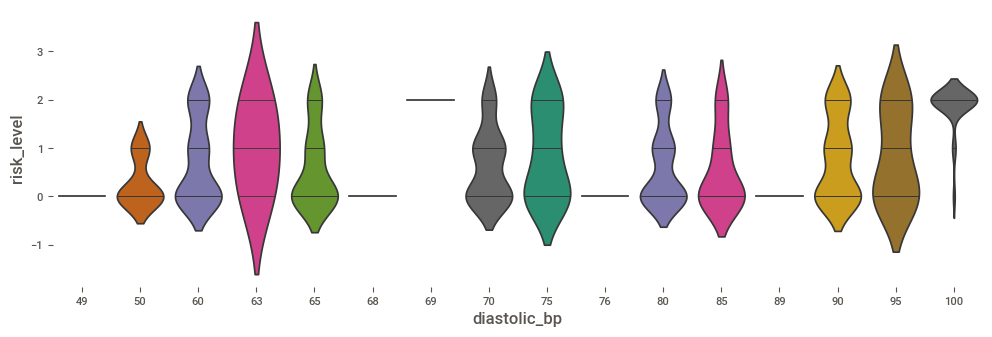

In [ ]:
# @title Зависимость уровня риска от систолического давления
figsize = (12, 1.2 * len(risk['risk_level'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(risk, x='diastolic_bp', y='risk_level', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

На графиках каких-то явных корреляций не видно. Лучше построить матрицу корреляций

<Axes: >

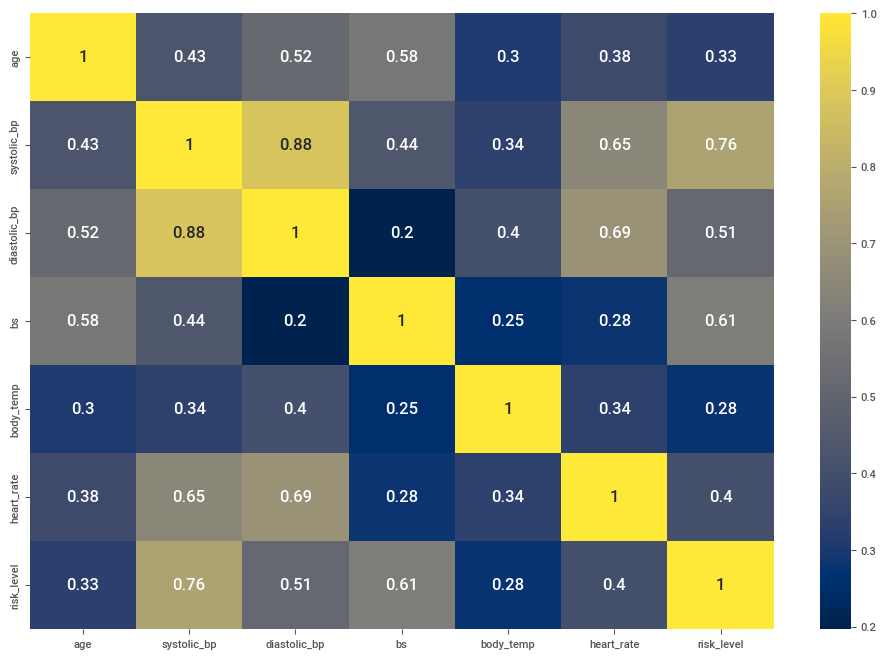

In [ ]:
interval_cols1 = ['age', 'systolic_bp', 'diastolic_bp', 'bs', 'body_temp', 'heart_rate']
plt.figure(figsize = (12,8))
sns.heatmap(risk.phik_matrix(interval_cols=interval_cols1), annot=True, cmap='cividis')

Матрица корреляций подсказывает нам очевидное: систолическое и диастолическое давление высоко коррелируют между собой, а также с ЧСС. Из этого можно сделать вывод, что данные корректны.
Что же касается целевого признака, то с ним коррелируют систолическое давление (0.76), глюкоза крови (0,61)  и диастолическое давление (0,51)

Пожалуй, есть смысл добавить новые признаки.

### Добавление новых признаков

Для начала создадим новый датасет, чтобы можно было сравнить результаты.

In [ ]:
df = risk.copy()

Добавим признак "разница между систолическим и диастолическим давлением". Он может оказаться важен.

In [ ]:
pressure_diff = risk['systolic_bp']-risk['diastolic_bp']
risk.insert(loc = 3,
          column = 'pressure_diff',
          value = pressure_diff)
risk.head(5)

,age,systolic_bp,diastolic_bp,pressure_diff,bs,body_temp,heart_rate,risk_level
0,25,130,80,50,15.0,98.0,86,2
1,35,140,90,50,13.0,98.0,70,2
2,29,90,70,20,8.0,100.0,80,2
3,30,140,85,55,7.0,98.0,70,2
4,35,120,60,60,6.1,98.0,76,0


Добавим столбец "отклонение сахара крови от нормы"

In [ ]:
bs_exc=risk['bs']-7

In [ ]:
risk.insert(loc = 5,
          column = 'bs_exc',
          value = bs_exc)

risk.loc[risk.bs_exc<0, 'bs_exc'] = 0

risk.head(5)

,age,systolic_bp,diastolic_bp,pressure_diff,bs,bs_exc,body_temp,heart_rate,risk_level
0,25,130,80,50,15.0,8.0,98.0,86,2
1,35,140,90,50,13.0,6.0,98.0,70,2
2,29,90,70,20,8.0,1.0,100.0,80,2
3,30,140,85,55,7.0,0.0,98.0,70,2
4,35,120,60,60,6.1,0.0,98.0,76,0


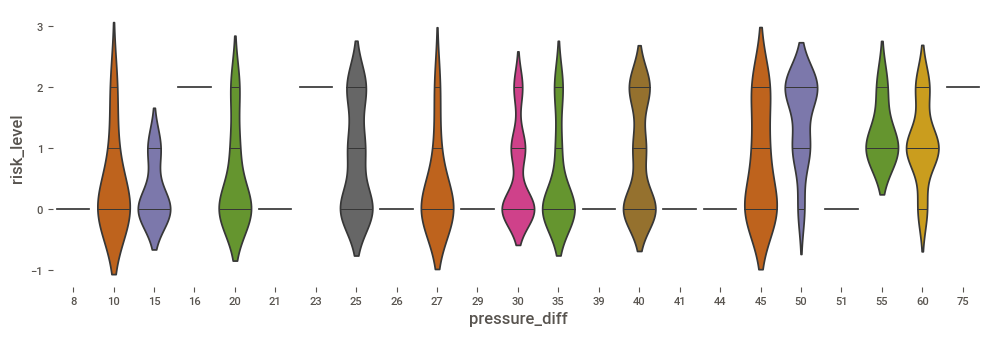

In [ ]:
# @title Зависимость уровня риска от разницы давлений
figsize = (12, 1.2 * len(risk['risk_level'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(risk, x='pressure_diff', y='risk_level', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

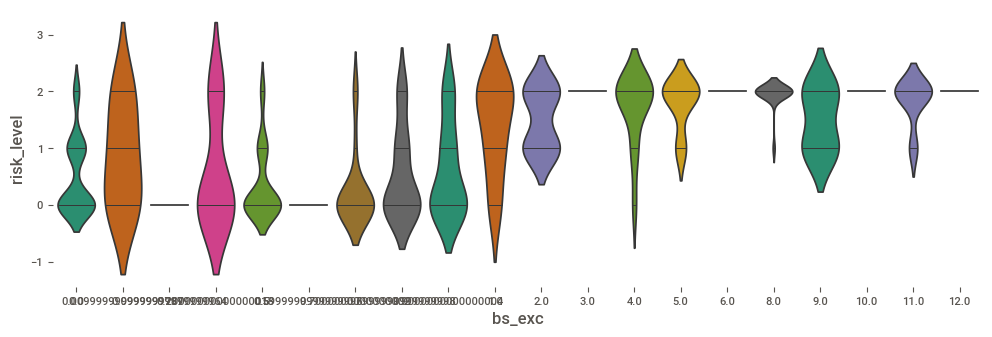

In [ ]:
# @title Зависимость уровня риска от превышения уровня сахара крови
figsize = (12, 1.2 * len(risk['risk_level'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(risk, x='bs_exc', y='risk_level', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

Видна корреляция низкого риска с значениями сахара близко к норме и норме

Посмотрим новую матрицу корреляций

<Axes: >

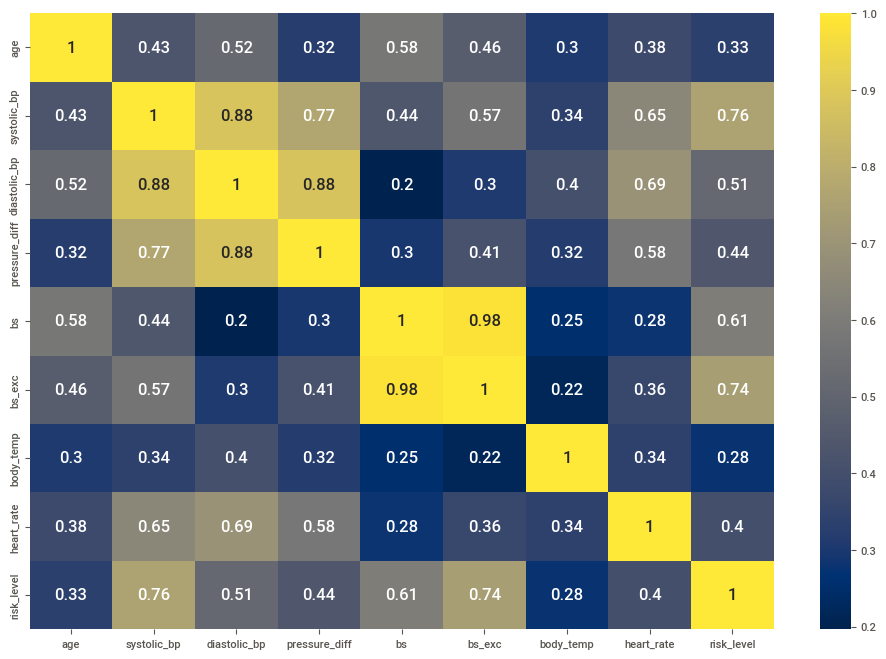

In [ ]:
interval_cols = ['age', 'systolic_bp', 'diastolic_bp', 'pressure_diff', 'bs', 'bs_exc', 'body_temp', 'heart_rate']
plt.figure(figsize = (12,8))
sns.heatmap(risk.phik_matrix(interval_cols=interval_cols), annot=True, cmap='cividis')

По матрице корреляций мы видим, что наш новый признак отклонение уровня сахара от нормы дает высокую корреляцию с целевым признаком.

Удаляем признак "сахар крови", так как они с превышением высокоскоррелированы.

In [ ]:
risk = risk.drop('bs', axis = 1)

## Baseline model

Напомним себе требования к работе:
- train test split = 70/30, stratified, Random state  - 654321 до генерации признаков и заполнения пропусков.
- Метрика - F1 Macro.
- Из тестовой выборки пациентов не удаляем.
- Целевой признак - "risk_level"

В данной работе выбраны две метрики: F1-мера и ROC AUC OVO/

1. Тип оценки:
- F1-мера оценивает баланс между precision и recall
- ROC AUC OVO оценивает способность модели различать классы
2. Подход к вычислению:
- F1-мера использует прямые метрики (TP, FP, FN)
- ROC AUC OVO строит кривые на основе вероятностей классов
3. Применение:
- F1-мера лучше подходит для оценки качества предсказаний в целом
- ROC AUC OVO лучше показывает способность модели различать классы при разных порогах
4. Чувствительность к дисбалансу:
- Обе метрики устойчивы к дисбалансу классов
- F1-мера более прямолинейно показывает качество на каждом классе
- ROC AUC OVO оценивает общую способность различать классы через вероятностные оценки

**В связи с вышеизложенным принято решение использовать обе метрики, так как они дают разные, но взаимодополняющие оценки качества модели.**

In [ ]:
# @title <font color='#4189ab'>def <font color='#d98007'>split_data_res_ind(df, target_column)
def split_data_res_ind(df, target_column):
    """
    Функция для разделения данных на обучающую и тестовую выборки с использованием стратификации.

    Параметры:
    df (pandas.DataFrame): исходный набор данных
    target_column (str): название столбца с целевыми значениями

    Должны быть определены константы
    TEST_SIZE (float): размер тестовой выборки (между 0 и 1)
    RANDOM_STATE (int): начальное значение для генератора случайных чисел
    STRATIFY (str): столбец для стратификации. Равен столбцу target или None.

    Возвращает:
    X_train (pandas.DataFrame): обучающая выборка без столбца с целевыми значениями
    X_test (pandas.DataFrame): тестовая выборка без столбца с целевыми значениями
    y_train (pandas.Series): целевые значения для обучающей выборки
    y_test (pandas.Series): целевые значения для тестовой выборки
    """
    # Удаляем целевой столбец из набора данных
    X = df.drop([target_column], axis=1)
    y = df[target_column]

    # Выполняем разделение данных
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        stratify=STRATIFY
    )
    X_train.reset_index(drop=True, inplace=True)
    X_test.reset_index(drop=True, inplace=True)
    y_train.reset_index(drop=True, inplace=True)
    y_test.reset_index(drop=True, inplace=True)

    return X_train, X_test, y_train, y_test

In [ ]:
STRATIFY = risk['risk_level']

In [ ]:
X_train, X_test, y_train, y_test = split_data_res_ind(risk, 'risk_level')
X_train.shape, X_test.shape

((316, 7), (136, 7))

In [ ]:
# @title <font color='#4189ab'>def <font color='#d98007'>plot_class_distribution_train_test(y_train, y_test, target)
def plot_class_distribution_train_test(y_train, y_test, target):
    """
    Функция для создания графика распределения осложнений в обучающей и тестовой выборках.

    Параметры:
    y_train (pandas.DataFrame): Обучающая выборка данных.
    y_test (pandas.DataFrame): Тестовая выборка данных.
    target (str): Название столбца с данными об осложнениях.
    """

    # Создание DataFrame для обучающей и тестовой выборок
    train = pd.DataFrame(y_train, columns=[target])
    test = pd.DataFrame(y_test, columns=[target])

    # Подготовка графиков
    fig, ax = plt.subplots(figsize=(6, 4))

    # Построение графиков для обучающей и тестовой выборок
    sns.countplot(data=train, y=target, alpha=.5, ax=ax)
    sns.countplot(data=test, y=target, alpha=1, ax=ax)

    # Добавление заголовка к графику
    ax.set_title('Разделение по классам')

    # Отображение графика
    plt.show()

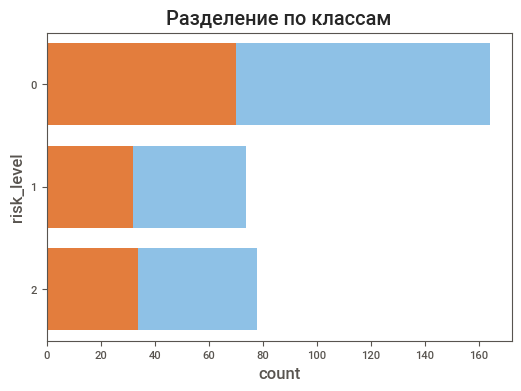

In [ ]:
plot_class_distribution_train_test(y_train, y_test, 'risk_level')

In [ ]:
# Create CatBoost pools for training and testing
train_pool = Pool(data=X_train, label=y_train,

                  )
test_pool = Pool(data=X_test, label=y_test,
                 #cat_features=categorical_featurs
                 )

# Обучение модели CatBoost
model = CatBoostClassifier(iterations=500, learning_rate=0.05, depth=6, loss_function = 'MultiClass', nan_mode='Min', verbose=False)
model.fit(train_pool)

In [ ]:
# Оценка качества модели
predictions = model.predict(test_pool)
f1_baseline = f1_score(y_test, predictions, average='macro')
print("F1-score:", round(f1_baseline, 3))

# roc-auc ovo
# Для корректной работы roc_auc_score в режиме OVO нужно получить вероятности классов
probabilities = model.predict_proba(test_pool)
roc_auc_baseline = roc_auc_score(y_test, probabilities, multi_class='ovo', average='macro')
print("roc-auc ovo:", round(roc_auc_baseline, 3))

F1-score: 0.577
roc-auc ovo: 0.746


In [ ]:
# @title <font color='#4189ab'>def <font color='#d98007'>plot_confusion_matrix(y_test, predictions)
def plot_confusion_matrix(y_test, predictions, figsize=(4, 4)):
    """
    Функция для построения матрицы ошибок.

    Параметры:
    y_test (array): массив с истинными значениями.
    predictions (array): массив с предсказанными значениями.
    figsize (tuple, optional): размер фигуры.
    """

    # Создание графиков
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(figsize[0]*2, figsize[1]))

    # Добавление заголовка
    plt.suptitle('Confusion Matrix', fontsize=16)

    # Вычисление и построение матрицы ошибок
    cm = confusion_matrix(y_test, predictions)

    # Абсолютные значения
    hmap1 = sns.heatmap(cm, annot=True, cbar=False, cmap='GnBu', ax=ax1,
                       fmt='.0f', cbar_kws={'label': 'Counts'})
    ax1.set_title('Absolute Values')

    # Процентные значения
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    hmap2 = sns.heatmap(cm_percent, annot=True, cbar=False, cmap='GnBu', ax=ax2,
                       fmt='.2f', cbar_kws={'label': 'Percentages'})
    ax2.set_title('Percentage Values')

    # Добавление меток
    plt.ylabel('Actual')
    plt.xlabel('Predicted')

    # Настройка расположения элементов графика
    plt.tight_layout()

    # Сохранение графика в файл
    plt.savefig('cm.png', dpi=300)

    # Отображение графика
    plt.show()

    # Сброс стилей Seaborn к исходным
    sns.reset_orig()

In [ ]:
# @title <font color='#4189ab'>def <font color='#d98007'>plot_feature_importance(model, X_test)
def plot_feature_importance(model, X_test):
    """
    Функция для построения графика важности признаков модели.

    Параметры:
    model (объект модели): обученная модель, из которой извлекаются значения важности признаков.
    X_test_base (pandas.DataFrame): DataFrame с признаками для тестирования.
    """

    # Определение данных для графика
    plot_data = {
        'features': X_test.columns,
        'feature_importances': model.feature_importances_,
    }

    # Преобразование в DataFrame
    plot_data = pd.DataFrame(plot_data)

    # Фильтрация признаков с положительными значениями важности
    plot_data = plot_data[plot_data['feature_importances'] > 0]

    # Сортировка по убыванию важности признаков
    plot_data.sort_values(by='feature_importances', ascending=False, inplace=True)

    # Настройка и построение графика
    plt.figure(figsize=(10, 5))
    sns.barplot(x='feature_importances', y='features', data=plot_data)

    # Добавление заголовка
    plt.title('Важность признаков модели \n', fontsize=14, fontweight="bold")

    # Отображение графика
    plt.show()

    # Сброс стилей Seaborn к исходным
    sns.reset_orig()

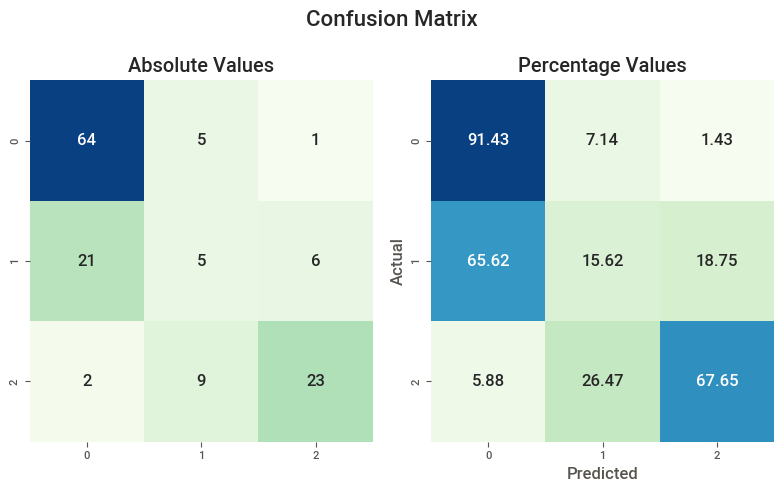

In [ ]:
plot_confusion_matrix(y_test, predictions, figsize=(4, 5))

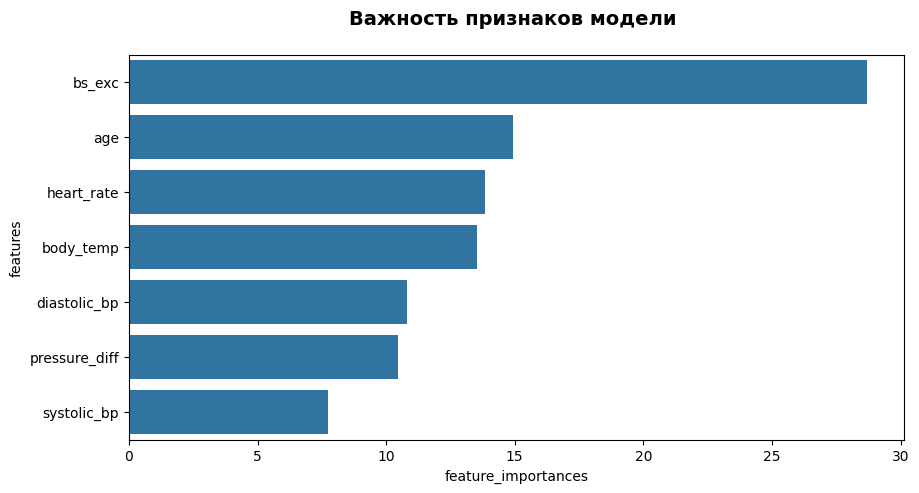

In [ ]:
plot_feature_importance(model, X_test)

## Модели

In [ ]:
# @title <font color='#4189ab'>def <font color='#d98007'>find_best_models
def find_best_models(X_train, y_train, X_test, y_test, models_params):
    '''
    Функция выполняет поиск лучшей модели из словаря,
    при этом осуществляется перебор с скейлером и без, скоринг по f1_macro,
    добавлена дополнительно метрика roc_auc_ovo
    '''
    best_models = []

    for model_name, (model, params) in models_params.items():
        # Создаем пайплайн без скалера
        pipeline_base = Pipeline([
            ('model', model)
        ])

        # Создаем пайплайн со скалером
        pipeline_scaled = Pipeline([
            ('scaler', StandardScaler()),
            ('model', model)
        ])

        # Проверяем обе версии модели
        for pipeline_name, pipeline in [
            ('base', pipeline_base),
            ('scaled', pipeline_scaled)
        ]:
            gs_model = GridSearchCV(
                pipeline,
                params,
                cv=5,
                scoring='f1_macro',
                n_jobs=-1
            )
            gs_model.fit(X_train, y_train)

            best_score = gs_model.best_score_
            best_estimator = gs_model.best_estimator_
            best_params = gs_model.best_params_

            # Получаем вероятности для ROC AUC на трейне
            y_pred_proba_train = best_estimator.predict_proba(X_train)
            roc_auc_ovo_train = roc_auc_score(y_train, y_pred_proba_train,
                                             multi_class='ovo',
                                             average='macro')

            # Делаем предсказание на тесте
            y_pred = best_estimator.predict(X_test)
            f1_test = f1_score(y_test, y_pred, average='macro')

            # Получаем вероятности для ROC AUC
            y_pred_proba = best_estimator.predict_proba(X_test)
            roc_auc_ovo = roc_auc_score(y_test, y_pred_proba,
                                       multi_class='ovo',
                                       average='macro')

            # Сохранение результатов
            best_models.append({
                'model_name': f'{model_name}_{pipeline_name}',
                'best_estimator': best_estimator,
                'best_params': best_params,
                'best_score_cv': best_score,
                'f1_test': f1_test,
                'roc_auc_ovo_train': roc_auc_ovo_train,
                'roc_auc_ovo': roc_auc_ovo
            })

            print(f'{model_name} ({pipeline_name}):')
            print(f'Метрика F1 Macro на кросс-валидации: {best_score:.3f}')
            print(f'Метрика F1 Macro на тесте: {f1_test:.3f}')
            print(f'Метрика ROC AUC OVO на трейне: {roc_auc_ovo_train:.3f}')
            print(f'Метрика ROC AUC OVO на тесте: {roc_auc_ovo:.3f}')
            print("Лучшая модель:", best_estimator)
            print('-'*40)

    return best_models

In [ ]:
# Параметры для логистической регрессии
lg_params_1 = {
    'model__penalty': ['l1'],
    'model__C': range(1, 25, 1),
    'model__solver': ['liblinear', 'saga'],
    'model__max_iter': [100, 200],
    'model__tol': [1e-4, 1e-2]
    }

lg_params_2 = {
    'model__penalty': ['l2'],
    'model__C': range(1, 25, 1),
    'model__solver': ['newton-cg', 'lbfgs', 'saga'],
    'model__max_iter': [100, 200],
    'model__tol': [1e-4, 1e-2]
    }

lg_params_3 = {
    'model__penalty': ['elasticnet'],
    'model__C': range(1, 25, 1),
    'model__solver': ['saga'],
    'model__max_iter': [100, 200],
    'model__tol': [1e-4, 1e-2],
    'model__l1_ratio': [0.5, 0.7, 0.9]
}


# Параметры для KNN
knn_params = {
        'model__n_neighbors': range(2, 10, 1),
        'model__leaf_size': range(10, 1000, 10),
        #'model__weights': ['uniform', 'distance'],
        #'model__algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute']
        }
# Словарь моделей и их параметров
models_params = {
    'LogisticRegression_1': (LogisticRegression(random_state=RANDOM_STATE), lg_params_1),
    'LogisticRegression_2': (LogisticRegression(random_state=RANDOM_STATE), lg_params_2),
    'LogisticRegression_3': (LogisticRegression(random_state=RANDOM_STATE), lg_params_3),
    'KNeighborsClassifier' : (KNeighborsClassifier(weights='distance'), knn_params)
}

# Вызов функции
best_models_list = find_best_models(X_train, y_train, X_test, y_test, models_params)

/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


LogisticRegression_1 (base):
Метрика F1 Macro на кросс-валидации: 0.567
Метрика F1 Macro на тесте: 0.542
Метрика ROC AUC OVO на трейне: 0.797
Метрика ROC AUC OVO на тесте: 0.727
Лучшая модель: Pipeline(steps=[('model',
                 LogisticRegression(C=21, max_iter=200, penalty='l1',
                                    random_state=654321, solver='liblinear'))])
----------------------------------------
LogisticRegression_1 (scaled):
Метрика F1 Macro на кросс-валидации: 0.576
Метрика F1 Macro на тесте: 0.531
Метрика ROC AUC OVO на трейне: 0.796
Метрика ROC AUC OVO на тесте: 0.729
Лучшая модель: Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 LogisticRegression(C=4, penalty='l1', random_state=654321,
                                    solver='liblinear'))])
----------------------------------------


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression_2 (base):
Метрика F1 Macro на кросс-валидации: 0.575
Метрика F1 Macro на тесте: 0.525
Метрика ROC AUC OVO на трейне: 0.736
Метрика ROC AUC OVO на тесте: 0.681
Лучшая модель: Pipeline(steps=[('model', LogisticRegression(C=24, random_state=654321))])
----------------------------------------
LogisticRegression_2 (scaled):
Метрика F1 Macro на кросс-валидации: 0.581
Метрика F1 Macro на тесте: 0.532
Метрика ROC AUC OVO на трейне: 0.795
Метрика ROC AUC OVO на тесте: 0.730
Лучшая модель: Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 LogisticRegression(C=1, random_state=654321, tol=0.01))])
----------------------------------------


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


LogisticRegression_3 (base):
Метрика F1 Macro на кросс-валидации: 0.560
Метрика F1 Macro на тесте: 0.525
Метрика ROC AUC OVO на трейне: 0.734
Метрика ROC AUC OVO на тесте: 0.678
Лучшая модель: Pipeline(steps=[('model',
                 LogisticRegression(C=2, l1_ratio=0.5, max_iter=200,
                                    penalty='elasticnet', random_state=654321,
                                    solver='saga'))])
----------------------------------------


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


LogisticRegression_3 (scaled):
Метрика F1 Macro на кросс-валидации: 0.572
Метрика F1 Macro на тесте: 0.532
Метрика ROC AUC OVO на трейне: 0.793
Метрика ROC AUC OVO на тесте: 0.732
Лучшая модель: Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 LogisticRegression(C=1, l1_ratio=0.7, penalty='elasticnet',
                                    random_state=654321, solver='saga'))])
----------------------------------------
KNeighborsClassifier (base):
Метрика F1 Macro на кросс-валидации: 0.512
Метрика F1 Macro на тесте: 0.512
Метрика ROC AUC OVO на трейне: 0.995
Метрика ROC AUC OVO на тесте: 0.651
Лучшая модель: Pipeline(steps=[('model',
                 KNeighborsClassifier(leaf_size=40, n_neighbors=7,
                                      weights='distance'))])
----------------------------------------
KNeighborsClassifier (scaled):
Метрика F1 Macro на кросс-валидации: 0.567
Метрика F1 Macro на тесте: 0.508
Метрика ROC AUC OVO на трейне: 0.995
Метрика 

In [ ]:
results_data = []

In [ ]:
def create_results_dataframe(best_models_list):
    global_results_data = []
    for model_info in best_models_list:
        results_data.append({
            'Model': model_info['model_name'],
            'Best Model': model_info['best_estimator'],
            'Best params': model_info['best_params'],
            'F1 CV': f"{model_info['best_score_cv']:.3f}",
            'F1 TEST': f"{model_info['f1_test']:.3f}",
            'ROC AUC OVO TRAIN': f"{model_info['roc_auc_ovo_train']:.3f}",
            'ROC AUC OVO TEST': f"{model_info['roc_auc_ovo']:.3f}"
        })
    return pd.DataFrame(results_data)

In [ ]:
create_results_dataframe(best_models_list)

,Model,Best Model,Best params,F1 CV,F1 TEST,ROC AUC OVO TRAIN,ROC AUC OVO TEST
0,LogisticRegression_1_base,"(LogisticRegression(C=21, max_iter=200, penalt...","{'model__C': 21, 'model__max_iter': 200, 'mode...",0.567,0.542,0.797,0.727
1,LogisticRegression_1_scaled,"(StandardScaler(), LogisticRegression(C=4, pen...","{'model__C': 4, 'model__max_iter': 100, 'model...",0.576,0.531,0.796,0.729
2,LogisticRegression_2_base,"(LogisticRegression(C=24, random_state=654321))","{'model__C': 24, 'model__max_iter': 100, 'mode...",0.575,0.525,0.736,0.681
3,LogisticRegression_2_scaled,"(StandardScaler(), LogisticRegression(C=1, ran...","{'model__C': 1, 'model__max_iter': 100, 'model...",0.581,0.532,0.795,0.730
4,LogisticRegression_3_base,"(LogisticRegression(C=2, l1_ratio=0.5, max_ite...","{'model__C': 2, 'model__l1_ratio': 0.5, 'model...",0.560,0.525,0.734,0.678
5,LogisticRegression_3_scaled,"(StandardScaler(), LogisticRegression(C=1, l1_...","{'model__C': 1, 'model__l1_ratio': 0.7, 'model...",0.572,0.532,0.793,0.732
6,KNeighborsClassifier_base,"(KNeighborsClassifier(leaf_size=40, n_neighbor...","{'model__leaf_size': 40, 'model__n_neighbors': 7}",0.512,0.512,0.995,0.651
7,KNeighborsClassifier_scaled,"(StandardScaler(), KNeighborsClassifier(leaf_s...","{'model__leaf_size': 10, 'model__n_neighbors': 8}",0.567,0.508,0.995,0.667


In [ ]:
# Параметры для дерева решений
dt_params = {
    'model__max_features': range(1, 28, 4),
    'model__max_depth': range(1, 20, 4),
    'model__min_samples_leaf': range(2, 5, 1),
    'model__min_samples_split': range(1,8,1),
    }
# Параметры для случайного леса
rf_params = {
    #'max_features': range(1, 20, 2), - если так смотреть, выбирает всегда 1
    'model__max_depth': range(1, 11, 2), #Проверяли до 25, все равно лучшая не выше 9
    'model__min_samples_leaf': range(2,12,2),
    'model__min_samples_split': range(2,8,2),
    }
# Параметры для LGBM
lgbm_params = {
    'model___estimators':  range(1, 20, 2),
    'model__learning_rate': [0.01, 0.1, 0.2],
    'model__verbosity': [-1]
    }


# Словарь моделей и их параметров
models_params = {
    'KNeighborsClassifier' : (KNeighborsClassifier(weights='distance'), knn_params),
    'DecisionTreeClassifier' : (DecisionTreeClassifier(random_state=RANDOM_STATE), dt_params),
    'RandomForestClassifier' : (RandomForestClassifier(random_state=RANDOM_STATE), rf_params),
    'LGBMClassifier' : (LGBMClassifier(random_state=RANDOM_STATE), lgbm_params),
    }

# Вызов функции
best_models_list = find_best_models(X_train, y_train, X_test, y_test, models_params)


KNeighborsClassifier (base):
Метрика F1 Macro на кросс-валидации: 0.512
Метрика F1 Macro на тесте: 0.512
Метрика ROC AUC OVO на трейне: 0.995
Метрика ROC AUC OVO на тесте: 0.651
Лучшая модель: Pipeline(steps=[('model',
                 KNeighborsClassifier(leaf_size=40, n_neighbors=7,
                                      weights='distance'))])
----------------------------------------
KNeighborsClassifier (scaled):
Метрика F1 Macro на кросс-валидации: 0.567
Метрика F1 Macro на тесте: 0.508
Метрика ROC AUC OVO на трейне: 0.995
Метрика ROC AUC OVO на тесте: 0.667
Лучшая модель: Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 KNeighborsClassifier(leaf_size=10, n_neighbors=8,
                                      weights='distance'))])
----------------------------------------


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [       nan 0.23608875 0.23608875 0.23608875 0.23608875 0.23608875
 0.23608875        nan 0.23608875 0.23608875 0.23608875 0.23608875
 0.23608875 0.23608875        nan 0.23608875 0.23608875 0.23608875
 0.23608875 0.23608875 0.23608875        nan 0.4891558  0.4891558
 0.4891558  0.4891558  0.4891558  0.4891558         nan 0.4891558
 0.4891558  0.4891558  0.4891558  0.4891558  0.4891558         nan
 0.4891558  0.4891558  0.4891558  0.4891558  0.4891558  0.4891558
        nan 0.4891558  0.4891558  0.4891558  0.4891558  0.4891558
 0.4891558         nan 0.4891558  0.4891558  0.4891558  0.4891558
 0.4891558  0.4891558         nan 0.4891558  0.4891558  0.4891558
 0.4891558  0.4891558  0.4891558         nan 0.4891558  0.4891558
 0.4891558  0.4891558  0.4891558  0.4891558         nan 0.4891558
 0.4891558  0.4891558  0.4891558  0.4891558  0.4891558         

DecisionTreeClassifier (base):
Метрика F1 Macro на кросс-валидации: 0.634
Метрика F1 Macro на тесте: 0.568
Метрика ROC AUC OVO на трейне: 0.870
Метрика ROC AUC OVO на тесте: 0.757
Лучшая модель: Pipeline(steps=[('model',
                 DecisionTreeClassifier(max_depth=5, max_features=5,
                                        min_samples_leaf=4,
                                        random_state=654321))])
----------------------------------------


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [       nan 0.23608875 0.23608875 0.23608875 0.23608875 0.23608875
 0.23608875        nan 0.23608875 0.23608875 0.23608875 0.23608875
 0.23608875 0.23608875        nan 0.23608875 0.23608875 0.23608875
 0.23608875 0.23608875 0.23608875        nan 0.4891558  0.4891558
 0.4891558  0.4891558  0.4891558  0.4891558         nan 0.4891558
 0.4891558  0.4891558  0.4891558  0.4891558  0.4891558         nan
 0.4891558  0.4891558  0.4891558  0.4891558  0.4891558  0.4891558
        nan 0.4891558  0.4891558  0.4891558  0.4891558  0.4891558
 0.4891558         nan 0.4891558  0.4891558  0.4891558  0.4891558
 0.4891558  0.4891558         nan 0.4891558  0.4891558  0.4891558
 0.4891558  0.4891558  0.4891558         nan 0.4891558  0.4891558
 0.4891558  0.4891558  0.4891558  0.4891558         nan 0.4891558
 0.4891558  0.4891558  0.4891558  0.4891558  0.4891558         

DecisionTreeClassifier (scaled):
Метрика F1 Macro на кросс-валидации: 0.634
Метрика F1 Macro на тесте: 0.584
Метрика ROC AUC OVO на трейне: 0.870
Метрика ROC AUC OVO на тесте: 0.781
Лучшая модель: Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 DecisionTreeClassifier(max_depth=5, max_features=5,
                                        min_samples_leaf=4,
                                        random_state=654321))])
----------------------------------------
RandomForestClassifier (base):
Метрика F1 Macro на кросс-валидации: 0.635
Метрика F1 Macro на тесте: 0.576
Метрика ROC AUC OVO на трейне: 0.939
Метрика ROC AUC OVO на тесте: 0.772
Лучшая модель: Pipeline(steps=[('model',
                 RandomForestClassifier(max_depth=7, min_samples_leaf=2,
                                        random_state=654321))])
----------------------------------------
RandomForestClassifier (scaled):
Метрика F1 Macro на кросс-валидации: 0.640
Метрика F1 Macro на те

In [ ]:
create_results_dataframe(best_models_list)

,Model,Best Model,Best params,F1 CV,F1 TEST,ROC AUC OVO TRAIN,ROC AUC OVO TEST
0,LogisticRegression_1_base,"(LogisticRegression(C=21, max_iter=200, penalt...","{'model__C': 21, 'model__max_iter': 200, 'mode...",0.567,0.542,0.797,0.727
1,LogisticRegression_1_scaled,"(StandardScaler(), LogisticRegression(C=4, pen...","{'model__C': 4, 'model__max_iter': 100, 'model...",0.576,0.531,0.796,0.729
2,LogisticRegression_2_base,"(LogisticRegression(C=24, random_state=654321))","{'model__C': 24, 'model__max_iter': 100, 'mode...",0.575,0.525,0.736,0.681
3,LogisticRegression_2_scaled,"(StandardScaler(), LogisticRegression(C=1, ran...","{'model__C': 1, 'model__max_iter': 100, 'model...",0.581,0.532,0.795,0.730
4,LogisticRegression_3_base,"(LogisticRegression(C=2, l1_ratio=0.5, max_ite...","{'model__C': 2, 'model__l1_ratio': 0.5, 'model...",0.560,0.525,0.734,0.678
5,LogisticRegression_3_scaled,"(StandardScaler(), LogisticRegression(C=1, l1_...","{'model__C': 1, 'model__l1_ratio': 0.7, 'model...",0.572,0.532,0.793,0.732
6,KNeighborsClassifier_base,"(KNeighborsClassifier(leaf_size=40, n_neighbor...","{'model__leaf_size': 40, 'model__n_neighbors': 7}",0.512,0.512,0.995,0.651
7,KNeighborsClassifier_scaled,"(StandardScaler(), KNeighborsClassifier(leaf_s...","{'model__leaf_size': 10, 'model__n_neighbors': 8}",0.567,0.508,0.995,0.667
8,KNeighborsClassifier_base,"(KNeighborsClassifier(leaf_size=40, n_neighbor...","{'model__leaf_size': 40, 'model__n_neighbors': 7}",0.512,0.512,0.995,0.651
9,KNeighborsClassifier_scaled,"(StandardScaler(), KNeighborsClassifier(leaf_s...","{'model__leaf_size': 10, 'model__n_neighbors': 8}",0.567,0.508,0.995,0.667


In [ ]:
result = pd.DataFrame(results_data).drop('Best Model', axis = 1)
#result

In [ ]:
# Параметры для Catboost
catb_params = {
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__depth': [3, 5, 7]
    }
# Словарь моделей и их параметров
models_params = {
    'CatBoostClassifier' : (CatBoostClassifier(random_state=RANDOM_STATE,
                               iterations=1000,
                               loss_function = 'MultiClass',
                               verbose=False
                               ), catb_params)

}

# Вызов функции
best_models_list = find_best_models(X_train, y_train, X_test, y_test, models_params)

CatBoostClassifier (base):
Метрика F1 Macro на кросс-валидации: 0.643
Метрика F1 Macro на тесте: 0.595
Метрика ROC AUC OVO на трейне: 0.900
Метрика ROC AUC OVO на тесте: 0.782
Лучшая модель: Pipeline(steps=[('model',
                 <catboost.core.CatBoostClassifier object at 0x7e95c43e6990>)])
----------------------------------------
CatBoostClassifier (scaled):
Метрика F1 Macro на кросс-валидации: 0.643
Метрика F1 Macro на тесте: 0.595
Метрика ROC AUC OVO на трейне: 0.900
Метрика ROC AUC OVO на тесте: 0.782
Лучшая модель: Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 <catboost.core.CatBoostClassifier object at 0x7e959b133fd0>)])
----------------------------------------


In [ ]:
create_results_dataframe(best_models_list)

,Model,Best Model,Best params,F1 CV,F1 TEST,ROC AUC OVO TRAIN,ROC AUC OVO TEST
0,LogisticRegression_1_base,"(LogisticRegression(C=21, max_iter=200, penalt...","{'model__C': 21, 'model__max_iter': 200, 'mode...",0.567,0.542,0.797,0.727
1,LogisticRegression_1_scaled,"(StandardScaler(), LogisticRegression(C=4, pen...","{'model__C': 4, 'model__max_iter': 100, 'model...",0.576,0.531,0.796,0.729
2,LogisticRegression_2_base,"(LogisticRegression(C=24, random_state=654321))","{'model__C': 24, 'model__max_iter': 100, 'mode...",0.575,0.525,0.736,0.681
3,LogisticRegression_2_scaled,"(StandardScaler(), LogisticRegression(C=1, ran...","{'model__C': 1, 'model__max_iter': 100, 'model...",0.581,0.532,0.795,0.730
4,LogisticRegression_3_base,"(LogisticRegression(C=2, l1_ratio=0.5, max_ite...","{'model__C': 2, 'model__l1_ratio': 0.5, 'model...",0.560,0.525,0.734,0.678
5,LogisticRegression_3_scaled,"(StandardScaler(), LogisticRegression(C=1, l1_...","{'model__C': 1, 'model__l1_ratio': 0.7, 'model...",0.572,0.532,0.793,0.732
6,KNeighborsClassifier_base,"(KNeighborsClassifier(leaf_size=40, n_neighbor...","{'model__leaf_size': 40, 'model__n_neighbors': 7}",0.512,0.512,0.995,0.651
7,KNeighborsClassifier_scaled,"(StandardScaler(), KNeighborsClassifier(leaf_s...","{'model__leaf_size': 10, 'model__n_neighbors': 8}",0.567,0.508,0.995,0.667
8,KNeighborsClassifier_base,"(KNeighborsClassifier(leaf_size=40, n_neighbor...","{'model__leaf_size': 40, 'model__n_neighbors': 7}",0.512,0.512,0.995,0.651
9,KNeighborsClassifier_scaled,"(StandardScaler(), KNeighborsClassifier(leaf_s...","{'model__leaf_size': 10, 'model__n_neighbors': 8}",0.567,0.508,0.995,0.667


In [ ]:
# Параметры для Catboost
catb_params_2 = {
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__depth': [3, 5, 7],
    'model__l2_leaf_reg': [3, 5, 7],  # L2-регуляризация
    #'model__border_count': [64, 128, 256],  # Количество границ для категориальных признаков
    'model__random_strength': [0.5, 1.0, 1.5],  # Сила случайности при построении деревьев
    'model__bagging_temperature': [0.5, 1.0, 1.5],  # Температура бэггинга
    #'model__grow_policy': ['SymmetricTree', 'Depthwise'],  # Политика роста деревьев
    #'model__max_ctr_complexity': [1, 2, 3],  # Максимальная сложность CTR
    'model__od_type': ['IncToDec', 'Iter'],  # Тип обнаружения переобучения
    #'model__od_wait': [20, 50, 100]  # Количество итераций для остановки
}
# Словарь моделей и их параметров
models_params = {
    'CatBoostClassifier2' : (CatBoostClassifier(random_state=RANDOM_STATE,
                               iterations=1000,
                               loss_function = 'MultiClass',
                               verbose=False
                               ), catb_params_2)

}

# Вызов функции
best_models_list = find_best_models(X_train, y_train, X_test, y_test, models_params)

CatBoostClassifier2 (base):
Метрика F1 Macro на кросс-валидации: 0.646
Метрика F1 Macro на тесте: 0.610
Метрика ROC AUC OVO на трейне: 0.901
Метрика ROC AUC OVO на тесте: 0.784
Лучшая модель: Pipeline(steps=[('model',
                 <catboost.core.CatBoostClassifier object at 0x7e9598186bd0>)])
----------------------------------------
CatBoostClassifier2 (scaled):
Метрика F1 Macro на кросс-валидации: 0.646
Метрика F1 Macro на тесте: 0.610
Метрика ROC AUC OVO на трейне: 0.901
Метрика ROC AUC OVO на тесте: 0.784
Лучшая модель: Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 <catboost.core.CatBoostClassifier object at 0x7e95981b4d90>)])
----------------------------------------


In [ ]:
create_results_dataframe(best_models_list)

,Model,Best Model,Best params,F1 CV,F1 TEST,ROC AUC OVO TRAIN,ROC AUC OVO TEST
0,LogisticRegression_1_base,"(LogisticRegression(C=21, max_iter=200, penalt...","{'model__C': 21, 'model__max_iter': 200, 'mode...",0.567,0.542,0.797,0.727
1,LogisticRegression_1_scaled,"(StandardScaler(), LogisticRegression(C=4, pen...","{'model__C': 4, 'model__max_iter': 100, 'model...",0.576,0.531,0.796,0.729
2,LogisticRegression_2_base,"(LogisticRegression(C=24, random_state=654321))","{'model__C': 24, 'model__max_iter': 100, 'mode...",0.575,0.525,0.736,0.681
3,LogisticRegression_2_scaled,"(StandardScaler(), LogisticRegression(C=1, ran...","{'model__C': 1, 'model__max_iter': 100, 'model...",0.581,0.532,0.795,0.730
4,LogisticRegression_3_base,"(LogisticRegression(C=2, l1_ratio=0.5, max_ite...","{'model__C': 2, 'model__l1_ratio': 0.5, 'model...",0.560,0.525,0.734,0.678
5,LogisticRegression_3_scaled,"(StandardScaler(), LogisticRegression(C=1, l1_...","{'model__C': 1, 'model__l1_ratio': 0.7, 'model...",0.572,0.532,0.793,0.732
6,KNeighborsClassifier_base,"(KNeighborsClassifier(leaf_size=40, n_neighbor...","{'model__leaf_size': 40, 'model__n_neighbors': 7}",0.512,0.512,0.995,0.651
7,KNeighborsClassifier_scaled,"(StandardScaler(), KNeighborsClassifier(leaf_s...","{'model__leaf_size': 10, 'model__n_neighbors': 8}",0.567,0.508,0.995,0.667
8,KNeighborsClassifier_base,"(KNeighborsClassifier(leaf_size=40, n_neighbor...","{'model__leaf_size': 40, 'model__n_neighbors': 7}",0.512,0.512,0.995,0.651
9,KNeighborsClassifier_scaled,"(StandardScaler(), KNeighborsClassifier(leaf_s...","{'model__leaf_size': 10, 'model__n_neighbors': 8}",0.567,0.508,0.995,0.667


In [ ]:
result = pd.DataFrame(results_data).drop('Best Model', axis = 1)
result.sort_values('F1 CV', ascending=False).head(5)

,Model,Best params,F1 CV,F1 TEST,ROC AUC OVO TRAIN,ROC AUC OVO TEST
19,CatBoostClassifier2_scaled,"{'model__bagging_temperature': 0.5, 'model__de...",0.646,0.610,0.901,0.784
18,CatBoostClassifier2_base,"{'model__bagging_temperature': 0.5, 'model__de...",0.646,0.610,0.901,0.784
17,CatBoostClassifier_scaled,"{'model__depth': 3, 'model__learning_rate': 0.01}",0.643,0.595,0.900,0.782
16,CatBoostClassifier_base,"{'model__depth': 3, 'model__learning_rate': 0.01}",0.643,0.595,0.900,0.782
13,RandomForestClassifier_scaled,"{'model__max_depth': 7, 'model__min_samples_le...",0.640,0.582,0.939,0.774


### Выбор лучшей модели

In [ ]:
# Объявляем глобальную переменную
best_model = None

def find_best_model(results_data):
    """
    Функция для поиска лучшей модели по метрике F1 CV

    Параметры:
    results_data (list/dict): данные с результатами моделей

    Возвращает:
    best_model: модель с максимальным значением F1 CV
    """
    global best_model  # Указываем, что используем глобальную переменную

    try:
        # Создаем DataFrame из входных данных
        result_df = pd.DataFrame(results_data)

        # Находим индекс строки с максимальной метрикой
        best_model_index = result_df['F1 CV'].idxmax()

        # Получаем лучшую модель
        best_model = result_df.loc[best_model_index, 'Best Model']

        # Выводим результат
        print(f"Лучшая модель: {best_model}")
        return best_model

    except Exception as e:
        print(f"Ошибка при поиске лучшей модели: {e}")
        return None

In [ ]:
find_best_model(results_data)

Лучшая модель: Pipeline(steps=[('model',
                 <catboost.core.CatBoostClassifier object at 0x7e9598186bd0>)])


Pipeline(steps=[('model',
                 <catboost.core.CatBoostClassifier object at 0x7e9598186bd0>)])

In [ ]:
result_df = pd.DataFrame(results_data)
# Находим индекс строки с максимальной метрикой на тесте
best_model_index = result_df['F1 CV'].idxmax()

# Получаем лучшую модель
best_model = result_df.loc[best_model_index, 'Best Model']

# Сохраняем лучшую модель в переменную
best_model = best_model

# Вывод лучшей модели
print(f"Лучшая модель: {best_model}")

Лучшая модель: Pipeline(steps=[('model',
                 <catboost.core.CatBoostClassifier object at 0x7e9598186bd0>)])


In [ ]:
# Функция для сохранения результатов
def save_results(best_model, filename='best_model.pkl'):
    joblib.dump(best_model, filename)
    print(f"Результаты сохранены в файл: {filename}")
# Функция для загрузки результатов
def load_results(filename='best_models.pkl'):
    return joblib.load(filename)

# Пример использования:
# loaded_models = load_results()
# analyze_results(loaded_models)

In [ ]:
# Сохраняем лучшую модель в файл
save_results(best_model, filename='best_model.pkl')

Результаты сохранены в файл: best_model.pkl


### Важность признаков лучшей модели

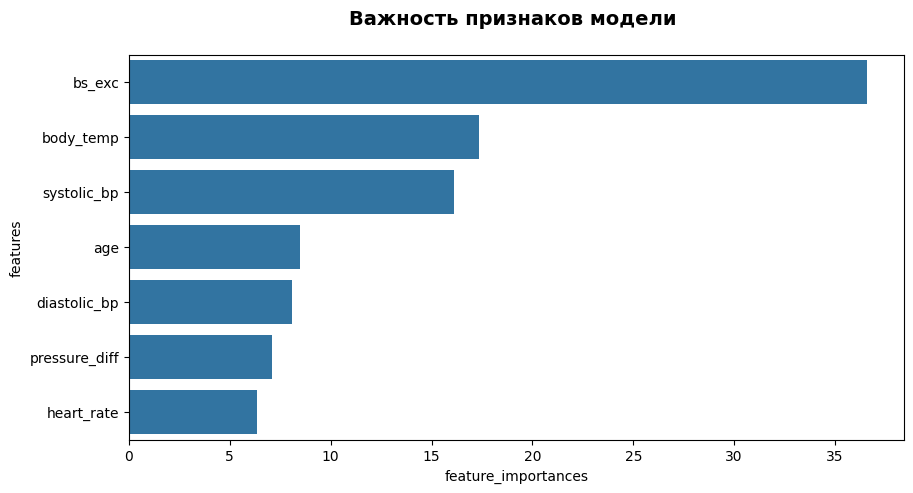

In [ ]:
# Получаем доступ к модели внутри Pipeline
catboost_model = best_model.named_steps['model']

plot_feature_importance(catboost_model, X_test)

Наиболее важный признак "степени ИМТ", холестерин занимает 3. строчку по важности. Также оказывается важен и день операции.

In [ ]:
# @title <font color='#4189ab'>def <font color='#d98007'>dummy_f1_score(X_train, y_train, X_test, y_test)
def dummy_f1_score(X_train, y_train, X_test, y_test):
    """
    Функция для вычисления F1-score для DummyClassifier.

    Параметры:
    X_train (pandas.DataFrame): Обучающие данные.
    y_train (pandas.Series): Обучающие метки.
    X_test (pandas.DataFrame): Тестовые данные.
    y_test (pandas.Series): Тестовые метки.

    Возвращает:
    float: F1-score для DummyClassifier.
    """

    # Инициализация и обучение DummyClassifier
    dummy_mean = DummyClassifier()
    dummy_mean.fit(X_train, y_train)

    # Прогнозирование на тестовых данных и вычисление F1-score
    dummy_prediction = dummy_mean.predict(X_test)
    f1_dummy = f1_score(y_test, dummy_prediction, average='macro')

    # Округление и вывод результата
    f1_dummy = round(abs(f1_dummy), 3)
    print(f'F1 Macro DummyClassifier = {f1_dummy}')

    return f1_dummy


In [ ]:
dummy_f1_score(X_train, y_train, X_test, y_test)

F1 Macro DummyRegressor = 0.227


0.227

Делаем вывод, что обученная модель адекватна, поскольку простая модель показывает метрику в разы хуже.

In [ ]:
# Выводим строку с максимальным значением F1 TEST
display(result.loc[[best_model_index]])

,Model,Best params,F1 CV,F1 TEST,ROC AUC OVO TRAIN,ROC AUC OVO TEST
18,CatBoostClassifier2_base,"{'model__bagging_temperature': 0.5, 'model__de...",0.646,0.610,0.901,0.784


Метрики F1 macro отличаются на 0,036 в пользу тренировочной выборки.
Значения близкие, что говорит о том, что модель хорошо обучилась

Выведем матрицу ошибок:

In [ ]:
y_pred = best_model.predict(X_test)

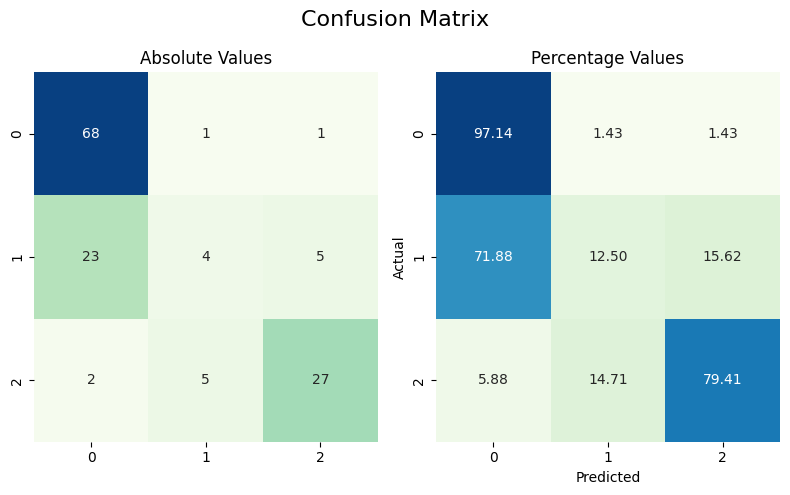

In [ ]:
plot_confusion_matrix(y_test, y_pred, figsize=(4, 5))

### Балансировка классов

Поскольку модель плохо предсказывает средний риск (класс 1), можно попробовать решить эту проблему при помощи балансировки классов, добавив в датасет представителей данного класса.

In [ ]:
!pip install imbalanced-learn -q
from imblearn.over_sampling import SMOTE

# Сначала посчитаем количество образцов в каждом классе
class_counts = np.bincount(y_train)

# Рассчитаем целевое количество для класса 1
target_count_class_1 = class_counts[1] * 2

# Создаем словарь с целевыми пропорциями
sampling_strategy = {
    0: class_counts[0],  # оставляем количество класса 0 прежним
    1: target_count_class_1,  # увеличиваем класс 1 в 2 раза
    2: class_counts[2]  # оставляем количество класса 2 прежним
}

# Создаем объект SMOTE с нужными параметрами
smote = SMOTE(sampling_strategy=sampling_strategy, random_state=RANDOM_STATE)

# Применяем SMOTE к обучающей выборке
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

# Проверяем результат
print("Исходное распределение классов:")
print(np.bincount(y_train))
print("\nНовое распределение классов:")
print(np.bincount(y_resampled))

Исходное распределение классов:
[164  74  78]

Новое распределение классов:
[164 148  78]


In [ ]:
result.loc[[best_model_index], 'Best params'].values[0]

{'model__bagging_temperature': 0.5,
 'model__depth': 3,
 'model__l2_leaf_reg': 3,
 'model__learning_rate': 0.01,
 'model__od_type': 'IncToDec',
 'model__random_strength': 1.5}

In [ ]:
# Параметры для Catboost
catb_params_2_balanced = {
    'model__learning_rate': [0.01],
    'model__depth': [3],
    'model__l2_leaf_reg': [3],  # L2-регуляризация
    'model__random_strength': [1.5],  # Сила случайности при построении деревьев
    'model__bagging_temperature': [0.5],  # Температура бэггинга
    'model__od_type': ['IncToDec'],  # Тип обнаружения переобучения
    }
# Словарь моделей и их параметров
models_params = {
    'CatBoostClassifier2_Balanced' : (CatBoostClassifier(random_state=RANDOM_STATE,
                               iterations=1000,
                               loss_function = 'MultiClass',
                               verbose=False
                               ), catb_params_2_balanced)

}

# Вызов функции
best_models_list = find_best_models(X_resampled, y_resampled, X_test, y_test, models_params)

CatBoostClassifier2_Balanced (base):
Метрика F1 Macro на кросс-валидации: 0.659
Метрика F1 Macro на тесте: 0.653
Метрика ROC AUC OVO на трейне: 0.920
Метрика ROC AUC OVO на тесте: 0.774
Лучшая модель: Pipeline(steps=[('model',
                 <catboost.core.CatBoostClassifier object at 0x7e959b132c50>)])
----------------------------------------
CatBoostClassifier2_Balanced (scaled):
Метрика F1 Macro на кросс-валидации: 0.659
Метрика F1 Macro на тесте: 0.653
Метрика ROC AUC OVO на трейне: 0.920
Метрика ROC AUC OVO на тесте: 0.774
Лучшая модель: Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 <catboost.core.CatBoostClassifier object at 0x7e95981b4890>)])
----------------------------------------


In [ ]:
create_results_dataframe(best_models_list)

,Model,Best Model,Best params,F1 CV,F1 TEST,ROC AUC OVO TRAIN,ROC AUC OVO TEST
0,LogisticRegression_1_base,"(LogisticRegression(C=21, max_iter=200, penalt...","{'model__C': 21, 'model__max_iter': 200, 'mode...",0.567,0.542,0.797,0.727
1,LogisticRegression_1_scaled,"(StandardScaler(), LogisticRegression(C=4, pen...","{'model__C': 4, 'model__max_iter': 100, 'model...",0.576,0.531,0.796,0.729
2,LogisticRegression_2_base,"(LogisticRegression(C=24, random_state=654321))","{'model__C': 24, 'model__max_iter': 100, 'mode...",0.575,0.525,0.736,0.681
3,LogisticRegression_2_scaled,"(StandardScaler(), LogisticRegression(C=1, ran...","{'model__C': 1, 'model__max_iter': 100, 'model...",0.581,0.532,0.795,0.730
4,LogisticRegression_3_base,"(LogisticRegression(C=2, l1_ratio=0.5, max_ite...","{'model__C': 2, 'model__l1_ratio': 0.5, 'model...",0.560,0.525,0.734,0.678
5,LogisticRegression_3_scaled,"(StandardScaler(), LogisticRegression(C=1, l1_...","{'model__C': 1, 'model__l1_ratio': 0.7, 'model...",0.572,0.532,0.793,0.732
6,KNeighborsClassifier_base,"(KNeighborsClassifier(leaf_size=40, n_neighbor...","{'model__leaf_size': 40, 'model__n_neighbors': 7}",0.512,0.512,0.995,0.651
7,KNeighborsClassifier_scaled,"(StandardScaler(), KNeighborsClassifier(leaf_s...","{'model__leaf_size': 10, 'model__n_neighbors': 8}",0.567,0.508,0.995,0.667
8,KNeighborsClassifier_base,"(KNeighborsClassifier(leaf_size=40, n_neighbor...","{'model__leaf_size': 40, 'model__n_neighbors': 7}",0.512,0.512,0.995,0.651
9,KNeighborsClassifier_scaled,"(StandardScaler(), KNeighborsClassifier(leaf_s...","{'model__leaf_size': 10, 'model__n_neighbors': 8}",0.567,0.508,0.995,0.667


In [ ]:
find_best_model(results_data)

Лучшая модель: Pipeline(steps=[('model',
                 <catboost.core.CatBoostClassifier object at 0x7e959b132c50>)])


Pipeline(steps=[('model',
                 <catboost.core.CatBoostClassifier object at 0x7e959b132c50>)])

In [ ]:
# Сохраняем лучшую модель в файл
save_results(best_model, filename='best_model.pkl')

Результаты сохранены в файл: best_model.pkl


In [ ]:
preds_balance = best_model.predict(X_test)

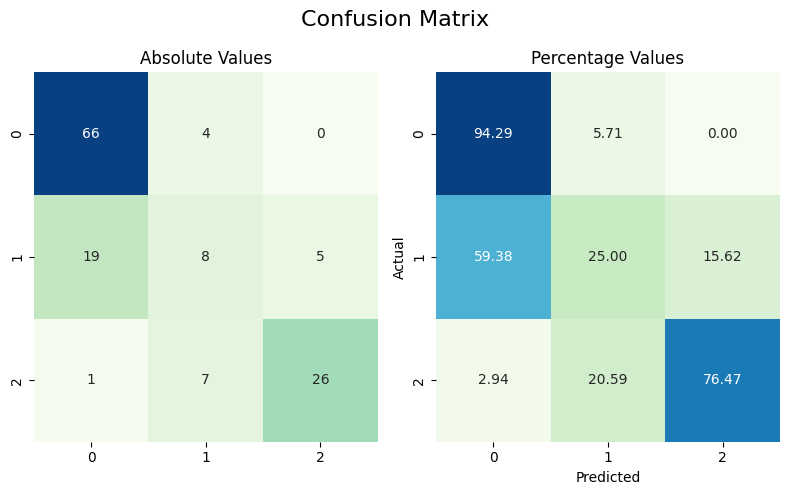

In [ ]:
plot_confusion_matrix(y_test, preds_balance, figsize=(4, 5))

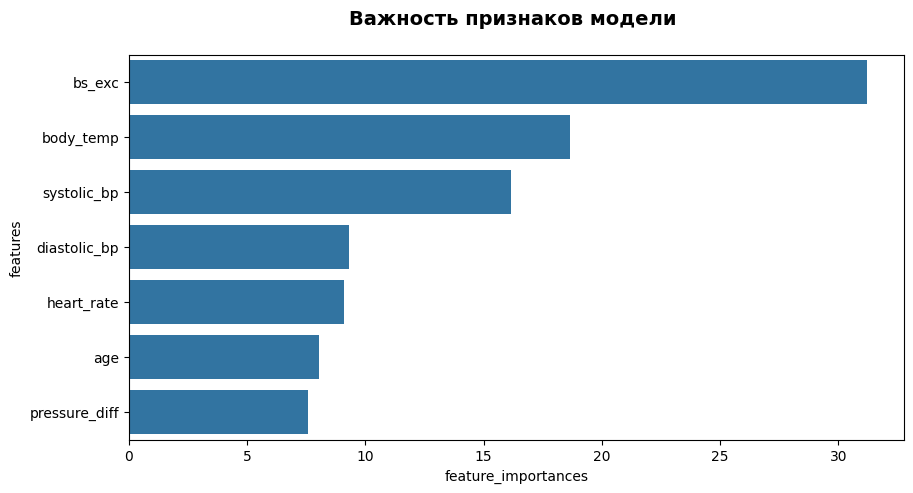

In [ ]:
catboost_model = best_model.named_steps['model']
plot_feature_importance(catboost_model, X_test)

### Стэкинг

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import StackingClassifier
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
# Создаем базовые классификаторы
estimators = [
    ('best_model', best_model),  # убедитесь, что best_model определен
    ('rf', RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)),
    ('svm', SVC(probability=True, kernel='rbf', random_state=RANDOM_STATE)),
    ('lr', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
]

# Создаем финальный классификатор с кросс-валидацией F1
final_estimator = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
)

# Добавляем расчет F1 через кросс-валидацию
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
f1_cv = cross_val_score(final_estimator, X_train, y_train,
                        cv=cv, scoring='f1_macro', n_jobs=-1)

# Создаем стекинг классификатор
stack_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=final_estimator,
    cv=5,  # добавляем кросс-валидацию
    n_jobs=-1  # используем все доступные ядра
)

# Обучаем модель
stack_clf.fit(X_train, y_train)

# Метрики на тренировочном наборе
y_pred_proba_train = stack_clf.predict_proba(X_train)
roc_auc_ovo_train = roc_auc_score(y_train, y_pred_proba_train,
                                 multi_class='ovo',
                                 average='macro')

# Предсказание и метрики на тестовом наборе
y_pred = stack_clf.predict(X_test)
f1_test = f1_score(y_test, y_pred, average='macro')

y_pred_proba = stack_clf.predict_proba(X_test)
roc_auc_ovo = roc_auc_score(y_test, y_pred_proba,
                           multi_class='ovo',
                           average='macro')

# Выводим результаты
print(f"F1 Score (CV): {np.mean(f1_cv):.3f} ± {np.std(f1_cv):.3f}")
print(f"F1 Score (Test): {f1_test:.3f}")
print(f"ROC AUC (Train): {roc_auc_ovo_train:.3f}")
print(f"ROC AUC (Test): {roc_auc_ovo:.3f}")

F1 Score (CV): 0.541 ± 0.050
F1 Score (Test): 0.604
ROC AUC (Train): 0.816
ROC AUC (Test): 0.798


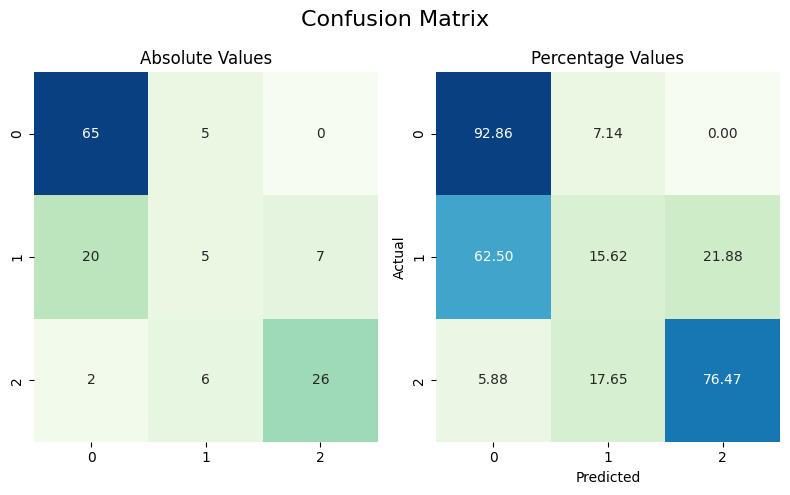

In [ ]:
plot_confusion_matrix(y_test, y_pred, figsize=(4, 5))

Стекинг ситуацию не улучшил.

# Выводы

### Исследовательский анализ

В датафрейме 1014 строк, нулевых значений нет.

В процессе исследовательского анализа данных из 1014 строк были удалены  562 полных дубликата.

Задача определена как задача мультиклассовой классификации - по данным о:
- возрасте,
- систолическом давлении,
- диастолическом давлении,
- сахаре крови,
- температуре тела
- ЧСС

необходимо сортировать риски на три категории: низкий риск, средний риск и высокий риск.

**Features**: 'age', 'systolic_bp', 'diastolic_bp', 'bs', 'body_temp', 'heart_rate'

**Target**: 'risk_level' (Values: 0, 1, 2)

Матрица корреляций подсказывает нам очевидное: систолическое и диастолическое давление высоко коррелируют между собой, а также с ЧСС. Из этого можно сделать вывод, что данные корректны. Что же касается целевого признака, то с ним коррелируют систолическое давление (0.76), глюкоза крови (0,61) и диастолическое давление (0,51)

Были добавлены новые признаки:
- разница давлений (систола - диастола)
- превышение сахара от нормы (за норму брала 7)

Был удален признак:
- сахар крови, так как высокоскоррелирован с новым признаком "превышение сахара от нормы"



<Axes: >

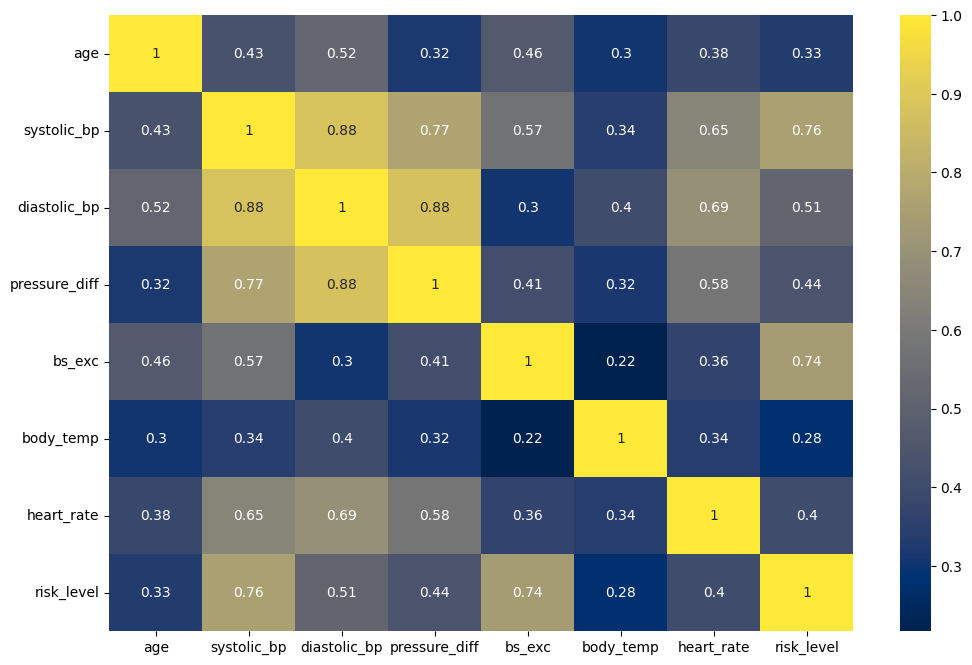

In [ ]:
interval_cols = ['age', 'systolic_bp', 'diastolic_bp', 'pressure_diff', 'bs', 'bs_exc', 'body_temp', 'heart_rate', 'risk_level']
plt.figure(figsize = (12,8))
sns.heatmap(risk.phik_matrix(interval_cols=interval_cols), annot=True, cmap='cividis')

По обновленной матрице корреляций видно, что новый признак отклонение уровня сахара от нормы дает высокую корреляцию с целевым признаком.

### Модели машинного обучения

Для обучения были выбраны модели:
- LogisticRegression
- KNeighboursClassifier
- DesigionTreeClassifier
- RandomForestClassifier
- LGBMClassifier
- CatBoostRegressor

Все они были обучены с предварительным масштабированием и без него, результаты занесены в таблицу.

После этого была выбрана лучшая модель. Это оказалась модель CatBoost с параметрами :

```python
{'model__bagging_temperature': 0.5,
 'model__depth': 3,
 'model__l2_leaf_reg': 3,
 'model__learning_rate': 0.01,
 'model__od_type': 'IncToDec',
 'model__random_strength': 1.5}
```

 После этого была построена матрица ошибок, по которой стало очевидно, что лучшая модель хорошо определяет класс низкого и высокого риска, а средний риск путает с низким.

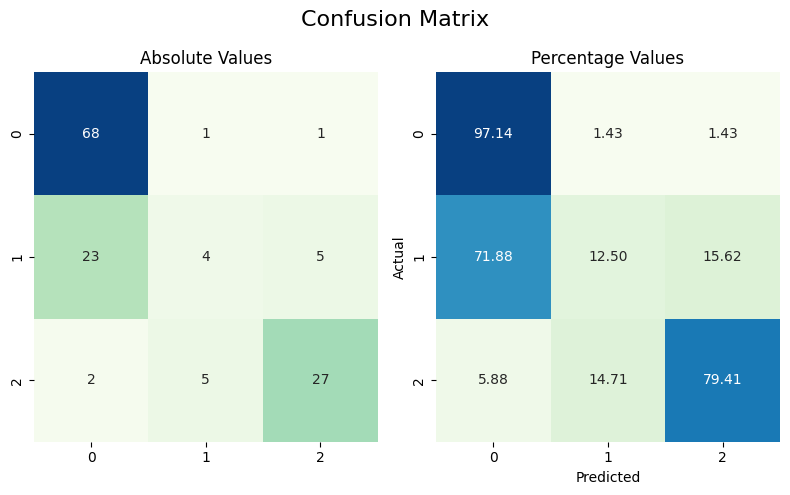

Было принято решение добавить синтетически представителей класса среднего риска, что и было сделано с использованием SMOTE.

 После этого на новых данных с добавлением синтетики была обучена модель catboost, для которой взяли лучшие параметры по кросс-валидации предыдущего шага. Данная модель показала себя лучше, угадывая уже 25% класс среднего риска против 12,5 в лучшей модели до балансировки данных.



In [ ]:
pd.DataFrame(results_data) \
    .drop(['Best Model', 'Best params'], axis=1) \
    .sort_values(by='F1 CV', ascending=False) \
    .head(6)


,Model,F1 CV,F1 TEST,ROC AUC OVO TRAIN,ROC AUC OVO TEST
21,CatBoostClassifier2_Balanced_scaled,0.659,0.653,0.920,0.774
20,CatBoostClassifier2_Balanced_base,0.659,0.653,0.920,0.774
19,CatBoostClassifier2_scaled,0.646,0.610,0.901,0.784
18,CatBoostClassifier2_base,0.646,0.610,0.901,0.784
17,CatBoostClassifier_scaled,0.643,0.595,0.900,0.782
16,CatBoostClassifier_base,0.643,0.595,0.900,0.782


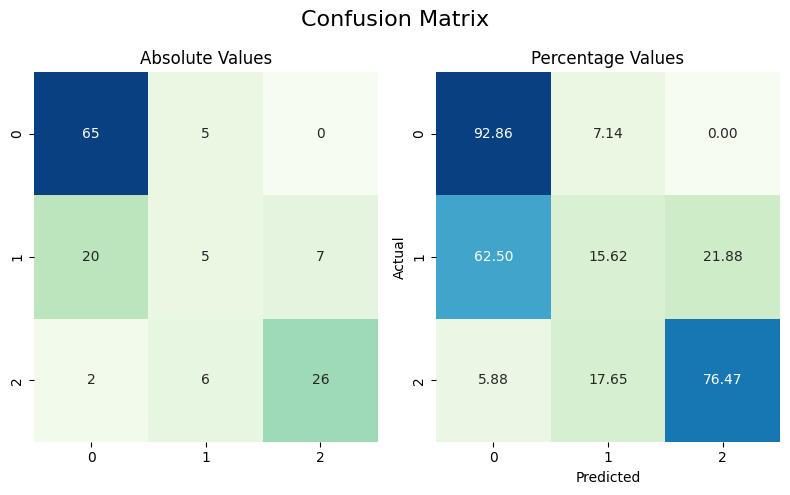

In [ ]:
plot_confusion_matrix(y_test, y_pred, figsize=(4, 5))